### Pemrosesan Data

#### Penjelasan

Data yang digunakan dalam laporan ini berasal dari survei Kesiapan dan Kapasitas Wilayah Program MBG.

Dari keseluruhan data survei, hanya data dengan status pengisian “Completed” yang digunakan agar analisis didasarkan pada informasi yang lengkap dan valid. Beberapa wilayah tidak disertakan dalam analisis, yaitu Provinsi NTB, NTT, Sulawesi Utara, dan Papua Pegunungan, dikarenakan provinsi tersebut belum mencapai target yang di iginkan, sehingga hasil analisis lebih konsisten dan sesuai dengan ruang lingkup kajian.

Data yang dianalisis terdiri dari 9 kelompok sumber, yaitu:
- Bulog terdapat (35, 246)
- Distributor terdapat (1424, 253)
- Hotel terdapat (2011, 170)
- Industri Makan terdapat (1226, 148)
- Penggiling terdapat (5665, 272)
- RTT terdapat (9674, 161)
- RTU terdapat (9758, 330)
- SPPG terdapat (408, 134)
- Supermarket terdapat (2743, 183)

#### Membaca Data Asli

In [1]:
import pandas as pd

dfs = {
    "Bulog": pd.read_excel("data/raw/bulog.xlsx", sheet_name="Sheet1"),
    "Distributor": pd.read_excel("data/raw/distributor.xlsx", sheet_name="Sheet1"),
    "Hotel": pd.read_excel("data/raw/hotel_rtk.xlsx", sheet_name="Sheet1"),
    "Industri Makan": pd.read_excel("data/raw/industri_makan.xlsx", sheet_name="Sheet1"),
    "Penggiling": pd.read_excel("data/raw/penggiling_pengumpul.xlsx", sheet_name="Sheet1"),
    "RTT": pd.read_excel("data/raw/rtt.xlsx", sheet_name="Sheet1"),
    "RTU": pd.read_excel("data/raw/rtu.xlsx", sheet_name="Sheet1"),
    "SPPG": pd.read_excel("data/raw/sppg.xlsx", sheet_name="Sheet1"),
    "Supermarket": pd.read_excel("data/raw/supermarket_pengecer.xlsx", sheet_name="Sheet1"),
}

c:\Users\gushi\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:223: UserWarning: Cell Y787 is marked as a date but the serial value 10000000.0 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
c:\Users\gushi\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:223: UserWarning: Cell Y1212 is marked as a date but the serial value 6000000.0 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
c:\Users\gushi\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:223: UserWarning: Cell Y1406 is marked as a date but the serial value 40000000.0 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
c:\Users\gushi\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:223: UserWarning: Cell Y445 is marked as a date but the serial value 21300000.0 is outside the lim

#### Meng-exclude prov

In [2]:
import pandas as pd

# 1. PROVINSI YANG DI-EXCLUDE
provinsi_exclude = [52, 53, 71, 95]

# 2. MAPPING KOLOM PROVINSI
provinsi_col = {
    "Supermarket": "A4",
    "SPPG": "A4",
    "RTU": "A3",
    "RTT": "A3",
    "Penggiling": "A4",
    "Industri Makan": "A4",
    "Hotel": "A4",
    "Distributor": "A3",
    "Bulog": "A4",
}

# 3. FILTER DATA
dfs_f = {}

for key, df in dfs.items():
    col_prov = provinsi_col.get(key)

    if col_prov not in df.columns:
        print(f"⚠️ {key}: kolom {col_prov} tidak ditemukan, dilewati")
        continue

    dfs_f[key] = df[
        (df["status"] == "COMPLETED") &
        (~df[col_prov].isin(provinsi_exclude))
    ]

    print(f"{key} filtered shape:", dfs_f[key].shape)

Bulog filtered shape: (35, 246)
Distributor filtered shape: (1424, 253)
Hotel filtered shape: (2011, 170)
Industri Makan filtered shape: (1226, 148)
Penggiling filtered shape: (5665, 272)
RTT filtered shape: (9674, 161)
RTU filtered shape: (9758, 330)
SPPG filtered shape: (408, 134)
Supermarket filtered shape: (2743, 183)


#### Save data raw 2

In [3]:
# import os

# # 1. FOLDER OUTPUT
# output_dir = r"C:\Users\gushi\OneDrive\Documents\Swakelola\analisis_kkw\data\raw2"
# os.makedirs(output_dir, exist_ok=True)

# # 2. LOOP SAVE PER DATASET
# for key, df in dfs_f.items():
#     # Nama file dibuat otomatis dari key
#     filename = f"{key.lower().replace(' ', '_')}_filtered.xlsx"
#     output_path = os.path.join(output_dir, filename)

#     # Simpan ke Excel
#     df.to_excel(output_path, index=False)

#     # Info ke terminal
#     print("=" * 50)
#     print(f"{key}")
#     print(f"Jumlah data : {df.shape[0]} baris, {df.shape[1]} kolom")
#     print(f"Disimpan ke : {output_path}")

In [4]:
import pandas as pd

data = pd.read_excel(
    r"C:\Users\gushi\OneDrive\Documents\Swakelola\analisis_kkw\data\raw2\bulog_filtered.xlsx"
)

print(data.head())

                  createdon                  finishon     createdby  \
0  2025-12-26T16:08:09.282Z  2025-12-26T16:22:43.992Z    kkw_papbar   
1  2025-12-25T21:35:32.454Z  2025-12-27T16:54:39.100Z    kkw_banten   
2  2025-12-27T20:00:29.221Z  2025-12-27T20:18:44.416Z    kkw_sumsel   
3  2025-12-27T06:55:30.600Z  2025-12-27T20:44:23.680Z   kkw_lampung   
4  2025-12-28T08:52:31.306Z  2025-12-28T09:16:53.037Z  kkw_bengkulu   

   kuesionerid     status                A1                             A2  \
0          618  COMPLETED        Andi Ashar            Staf pelaksana SCPP   
1          618  COMPLETED         Yuningsih                          Staff   
2          618  COMPLETED  Ahmad Fahmi azin                    Manager Ops   
3          618  COMPLETED  ARIE TRI NUGROHO  ASISTEN MANAJER SDM DAN HUKUM   
4          618  COMPLETED      Heru gunawan                        pegawai   

                           A3  A4    A5  ... E5[2].jumlah  C11_Import  \
0   Perum Bulog KC Manokwari   

In [5]:
# data['status'].sample(15)
data.columns

Index(['createdon', 'finishon', 'createdby', 'kuesionerid', 'status', 'A1',
       'A2', 'A3', 'A4', 'A5',
       ...
       'E5[2].jumlah', 'C11_Import', 'C14[5].alamat', 'C14[5].bentuk',
       'C14[5].satuan', 'C14[5].volume', 'C14[5].kategori', 'modifiedon',
       'status_delete', 'deletedon'],
      dtype='str', length=246)

#### Mengambil kolom

##### Penjelasan

Pada tahap selanjutnya, dilakukan pemilihan kolom data yang relevan dengan tujuan analisis. Tidak seluruh kolom dalam dataset digunakan, melainkan hanya kolom-kolom yang secara langsung mendukung analisis yang akan dilakukan.

Kolom yang dipilih meliputi:
- Nama responden
- Nomor telepon
- Status survei
- Informasi terkait jenis/mutu beras
- Informasi kemudahan akses pembelian beras
- Informasi sumber pembelian beras

Pemilihan kolom ini dilakukan karena fokus analisis adalah pada kualitas beras, kemudahan akses, serta rantai sumber pembelian beras pada masing-masing responden. Perlu diperhatikan bahwa data berasal dari 9 jenis sumber responden yang berbeda, sehingga nama kolom dan struktur pertanyaannya tidak sepenuhnya sama antar sumber data. Meskipun berbeda secara teknis, kolom-kolom tersebut memiliki makna yang setara, khususnya untuk variabel:
- Jenis/Mutu Beras
- Kemudahan Akses Beras
- Sumber Pembelian Beras

Oleh karena itu, pada tahap selanjutnya akan dilakukan penyesuaian dan pemetaan kolom agar seluruh data dapat dianalisis secara konsisten dan dapat dibandingkan antar sumber responden.

##### Bulog

In [6]:
# 1. Path file sumber
file_path = "data/raw2/bulog_filtered.xlsx"

# 2. Baca Excel (Sheet1)
data1 = pd.read_excel(file_path, sheet_name="Sheet1")

# 3. Daftar kolom yang ingin dipertahankan
kolom_dipilih = [
    "A1",
    "A7",
    "status",
    "C8[0].kategori",
    "C12",
    "C10[0]",
    "C10[1]",
    "C10[2]",
    "C10[3]"
]

# 4. Ambil hanya kolom tersebut (kolom lain otomatis terhapus)
df1 = data1[kolom_dipilih]

print(df1.head())


                 A1           A7     status  C8[0].kategori  C12 C10[0]  \
0        Andi Ashar  82199598579  COMPLETED             3.0    1  other   
1         Yuningsih    254213217  COMPLETED             NaN    1      1   
2  Ahmad Fahmi azin  85368482777  COMPLETED             NaN    1      1   
3  ARIE TRI NUGROHO  85768142530  COMPLETED             NaN    1      1   
4      Heru gunawan  85609774206  COMPLETED             NaN    1      1   

  C10[1] C10[2]  C10[3]  
0    NaN    NaN     NaN  
1      2    NaN     NaN  
2      4    NaN     NaN  
3      3      4     NaN  
4      4    NaN     NaN  


##### Distributor

In [7]:
# 1. Path file sumber
file_path = "data/raw2/distributor_filtered.xlsx"

# 2. Baca Excel (Sheet1)
data2 = pd.read_excel(file_path, sheet_name="Sheet1")

# 3. Daftar kolom yang ingin dipertahankan
kolom_dipilih = [
    "A1",
    "A10",
    "status",
    "C5[0].kategori",
    "C9",
    "C7[0]",
    "C7[1]",
    "C7[2]",
    "C7[3]",
    "C7[4]"
]

# 4. Ambil hanya kolom tersebut (kolom lain otomatis terhapus)
df2 = data2[kolom_dipilih]

print(df2.head())

        A1          A10     status  C5[0].kategori  C9 C7[0] C7[1] C7[2]  \
0     Yoyo  85643135005  COMPLETED             NaN   2     4     3     5   
1   Manita  85750784522  COMPLETED             2.0   1     4   NaN   NaN   
2    Marni  85651434704  COMPLETED             NaN   1     4   NaN   NaN   
3  Rubinah  85750424901  COMPLETED             NaN   1     4   NaN   NaN   
4    Firen  85183712929  COMPLETED             NaN   1     4   NaN   NaN   

  C7[3]  C7[4]  
0   NaN    NaN  
1   NaN    NaN  
2   NaN    NaN  
3   NaN    NaN  
4   NaN    NaN  


##### Hotel & RTK

In [8]:
# 1. Path file sumber
file_path = "data/raw2/hotel_filtered.xlsx"

# 2. Baca Excel (Sheet1)
data3 = pd.read_excel(file_path, sheet_name="Sheet1")

# 3. Daftar kolom yang ingin dipertahankan
kolom_dipilih = [
    "A1",
    "A11",
    "status",
    "C4[0].kategori",
    "C7",
    "C5[0]",
    "C5[1]",
    "C5[2]",
    "C5[3]",
    "C5[4]"
]

# 4. Ambil hanya kolom tersebut (kolom lain otomatis terhapus)
df3 = data3[kolom_dipilih]

print(df3.head())

           A1          A11     status C4[0].kategori   C7 C5[0] C5[1] C5[2]  \
0   Taharudin  85249805658  COMPLETED              4  1.0     4   NaN   NaN   
1  MUH. YUSUF  82336398104  COMPLETED              4  1.0     4   NaN   NaN   
2  MUH. RUSDI  82337668082  COMPLETED              4  1.0     2   NaN   NaN   
3     JUNAIDI  82116841114  COMPLETED              4  1.0     2   NaN   NaN   
4      Freedy   8351472333  COMPLETED              4  1.0     2   NaN   NaN   

   C5[3]  C5[4]  
0    NaN    NaN  
1    NaN    NaN  
2    NaN    NaN  
3    NaN    NaN  
4    NaN    NaN  


##### Industri Makan

In [9]:
# 1. Path file sumber
file_path = "data/raw2/industri_makan_filtered.xlsx"

# 2. Baca Excel (Sheet1)
data4 = pd.read_excel(file_path, sheet_name="Sheet1")

# 3. Daftar kolom yang ingin dipertahankan
kolom_dipilih = [
    "A1",
    "A11",
    "status",
    "C4[0].kategori",
    "C7",
    "C5[0]",
    "C5[1]",
    "C5[2]",
    "C5[3]" 									
]

# 4. Ambil hanya kolom tersebut (kolom lain otomatis terhapus)
df4 = data4[kolom_dipilih]

print(df4.head())

          A1          A11     status C4[0].kategori  C7 C5[0] C5[1] C5[2]  \
0   WAHYUDIN  85266438228  COMPLETED              3   1     2   NaN   NaN   
1  ARTA CIKA  85657136690  COMPLETED              4   1     4   NaN   NaN   
2      AHMAD  82192814460  COMPLETED              4   1     4   NaN   NaN   
3    Nurmala  85702114430  COMPLETED              4   1     4   NaN   NaN   
4   Rajianto  89696381555  COMPLETED              4   1     4   NaN   NaN   

   C5[3]  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


##### Penggiling Pengumpul

In [10]:
# 1. Path file sumber
file_path = "data/raw2/penggiling_filtered.xlsx"

# 2. Baca Excel (Sheet1)
data5 = pd.read_excel(file_path, sheet_name="Sheet1")

# 3. Daftar kolom yang ingin dipertahankan
kolom_dipilih = [
    "A1",
    "A12",
    "status",
    "C9[0].kategori",
    "C13",
    "C11[0]",
    "C11[1]",
    "C11[2]",
    "C11[3]" 																	
]

# 4. Ambil hanya kolom tersebut (kolom lain otomatis terhapus)
df5 = data5[kolom_dipilih]

print(df5.head())

            A1          A12     status C9[0].kategori  C13 C11[0] C11[1]  \
0       SAUNAI   8549830072  COMPLETED            NaN  2.0      1    NaN   
1        RATMI  81252405727  COMPLETED            NaN  2.0      1    NaN   
2        PARTI  85331503197  COMPLETED            NaN  2.0      1      2   
3  Samsudiarso  85100758198  COMPLETED            NaN  1.0      1    NaN   
4   SUPRIYANTO  82219402123  COMPLETED            NaN  1.0      1    NaN   

  C11[2] C11[3]  
0    NaN    NaN  
1    NaN    NaN  
2    NaN    NaN  
3    NaN    NaN  
4    NaN    NaN  


##### Rumah Tangga Tani

In [11]:
# 1. Path file sumber
file_path = "data/raw2/rtt_filtered.xlsx"

# 2. Baca Excel (Sheet1)
data6 = pd.read_excel(file_path, sheet_name="Sheet1")

# 3. Daftar kolom yang ingin dipertahankan
kolom_dipilih = [
    "A1",
    "A12",
    "status",
    "C21[0].kategori",
    "C22",
    "C16"																						
]

# 4. Ambil hanya kolom tersebut (kolom lain otomatis terhapus)
df6= data6[kolom_dipilih]

print(df6.head())

         A1          A12     status C21[0].kategori  C22  C16
0  syamsiah  85691867442  COMPLETED             NaN  NaN  NaN
1     Yayah  85811618080  COMPLETED             NaN  NaN  NaN
2    HAMADI  82255155414  COMPLETED               2  1.0    1
3   Maspuah  81410661339  COMPLETED             NaN  NaN  NaN
4    Sarmah  85691867443  COMPLETED             NaN  NaN  NaN


##### Rumah Tangga Umum

In [12]:
# 1. Path file sumber
file_path = "data/raw2/rtu_filtered.xlsx"

# 2. Baca Excel (Sheet1)
data7 = pd.read_excel(file_path, sheet_name="Sheet1")

# 3. Daftar kolom yang ingin dipertahankan
kolom_dipilih = [
    "A1",
    "A12",
    "status",
    "C6[0].kategori",
    "C7",
    "C1",
    "C1[0]",
    "C1[1]"																								
]

# 4. Ambil hanya kolom tersebut (kolom lain otomatis terhapus)
df7= data7[kolom_dipilih]

print(df7.head())

                  A1          A12     status C6[0].kategori   C7 C1  C1[0]  \
0      KETUT MARIANI  81348073063  COMPLETED              4  1.0  6    NaN   
1   KOMANG ADI PUTRA  85285927600  COMPLETED              4  1.0  6    NaN   
2  KADEK ANA SITIANI  85656685253  COMPLETED              3  1.0  6    NaN   
3      KADEK SARMIAN  85242040377  COMPLETED              3  1.0  6    NaN   
4      KADEK RULIANI  82298180952  COMPLETED              3  1.0  6    NaN   

   C1[1]  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


##### SPPG

In [13]:
# 1. Path file sumber
file_path = "data/raw2/sppg_filtered.xlsx"

# 2. Baca Excel (Sheet1)
data8 = pd.read_excel(file_path, sheet_name="Sheet1")

# 3. Daftar kolom yang ingin dipertahankan
kolom_dipilih = [
    "A1",
    "A11",
    "status",
    "C4[0].kategori",
    "C7",
    "C5[0]",
    "C5[1]",
    "C5[2]",
    "C5[3]" 															
]

# 4. Ambil hanya kolom tersebut (kolom lain otomatis terhapus)
df8 = data8[kolom_dipilih]

print(df8.head())

              A1          A11     status  C4[0].kategori  C7 C5[0] C5[1]  \
0           Dian  81354879348  COMPLETED               4   1     1     5   
1  MITHA HAMIDAH  82127858633  COMPLETED               4   1     3   NaN   
2   Ansori, S. H  81522987511  COMPLETED               4   1     1   NaN   
3        lestari   8236142329  COMPLETED               3   1     1     2   
4     gintra ari  82614729167  COMPLETED               3   1     1     2   

  C5[2]  C5[3]  
0   NaN    NaN  
1   NaN    NaN  
2   NaN    NaN  
3   NaN    NaN  
4   NaN    NaN  


##### Supermarket & Pengecer

In [14]:
# 1. Path file sumber
file_path = "data/raw2/supermarket_filtered.xlsx"

# 2. Baca Excel (Sheet1)
data9 = pd.read_excel(file_path, sheet_name="Sheet1")

# 3. Daftar kolom yang ingin dipertahankan
kolom_dipilih = [
    "A1",
    "A12",
    "status",
    "C5[0].kategori",
    "C6[0].kategori",
    "C6[1].kategori",
    "C6[2].kategori",
    "C9",
    "C7[0]",
    "C7[1]",
    "C7[2]",
    "C7[3]"
]

# 4. Ambil hanya kolom tersebut (kolom lain otomatis terhapus)
df9 = data9[kolom_dipilih]

print(df9.head())

                             A1          A12     status  C5[0].kategori  \
0                       Mujiati  89684250560  COMPLETED             2.0   
1  GUSTIANA HANDILAWATI SAFITRI  82379071816  COMPLETED             NaN   
2                        HAMIMI  82337810459  COMPLETED             NaN   
3                        M Robi  81110778043  COMPLETED             NaN   
4                       Subakti  87762393342  COMPLETED             3.0   

   C6[0].kategori C6[1].kategori C6[2].kategori  C9 C7[0] C7[1] C7[2] C7[3]  
0             NaN            NaN            NaN   1     4   NaN   NaN   NaN  
1             NaN            NaN            NaN   1     6   NaN   NaN   NaN  
2             3.0              3              2   1     6   NaN   NaN   NaN  
3             3.0              4              2   1     4     6   NaN   NaN  
4             NaN            NaN            NaN   1     3     4   NaN   NaN  


#### Save data 

- Save data yang hanya berisi kolom yang ingin di analisis (data processed.xlsx)

In [15]:
import pandas as pd
import os

# 1. FUNGSI SAVE DATA
def save_filtered_df(df, filename, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, filename)

    df.to_excel(output_path, index=False)

    print("=" * 50)
    print(f"Preview {filename}")
    print(df.head())
    print(f"\nFile berhasil disimpan di:\n{output_path}")

    return output_path

# 2. FOLDER OUTPUT 
output_dir = r"C:\Users\gushi\OneDrive\Documents\Swakelola\analisis_kkw\data\proses"


In [16]:
# 4. SAVE DATA (NAMA FILE DIGANTI)

datasets = {
    "bulog_processed.xlsx": df1,
    "distributor_processed.xlsx": df2,
    "hotel_processed.xlsx": df3,
    "industrimakan_processed.xlsx": df4,
    "penggiling_processed.xlsx": df5,
    "rtt_processed.xlsx": df6,
    "rtu_processed.xlsx": df7,
    "sppg_processed.xlsx": df8,
    "supermarket_processed.xlsx": df9,
}


for filename, df in datasets.items():
    save_filtered_df(
        df=df,
        filename=filename,
        output_dir=output_dir
    )

Preview bulog_processed.xlsx
                 A1           A7     status  C8[0].kategori  C12 C10[0]  \
0        Andi Ashar  82199598579  COMPLETED             3.0    1  other   
1         Yuningsih    254213217  COMPLETED             NaN    1      1   
2  Ahmad Fahmi azin  85368482777  COMPLETED             NaN    1      1   
3  ARIE TRI NUGROHO  85768142530  COMPLETED             NaN    1      1   
4      Heru gunawan  85609774206  COMPLETED             NaN    1      1   

  C10[1] C10[2]  C10[3]  
0    NaN    NaN     NaN  
1      2    NaN     NaN  
2      4    NaN     NaN  
3      3      4     NaN  
4      4    NaN     NaN  

File berhasil disimpan di:
C:\Users\gushi\OneDrive\Documents\Swakelola\analisis_kkw\data\proses\bulog_processed.xlsx
Preview distributor_processed.xlsx
        A1          A10     status  C5[0].kategori  C9 C7[0] C7[1] C7[2]  \
0     Yoyo  85643135005  COMPLETED             NaN   2     4     3     5   
1   Manita  85750784522  COMPLETED             2.0   1     

#### Pemeriksaan dan Pembersihan Data

##### Penjelasan

Sebelum seluruh data disatukan ke dalam kolom yang sama, dilakukan pemeriksaan dan pembersihan data untuk memastikan kualitas dan konsistensi data yang akan dianalisis. Tahapan ini mencakup pengecekan tipe data, data duplikat, dan missing value.

Kolom jenis/mutu beras, kemudahan akses memperoleh beras, dan sumber pembelian beras disesuaikan tipe datanya menjadi integer (int64) agar memudahkan proses pemetaan kategori dan analisis lanjutan.

Hasil pemeriksaan menunjukkan bahwa tidak terdapat missing value pada 9 jenis data yang digunakan, karena hanya data dengan isian yang lengkap yang dipertahankan. Data hanya akan dihapus apabila satu baris benar-benar tidak memiliki informasi (NaN), dan kondisi tersebut tidak ditemukan.

Untuk data duplikat, apabila terdapat entri yang sama, maka hanya satu data yang dipertahankan, sementara duplikat lainnya dihapus agar tidak terjadi penghitungan ganda.

Tahapan ini memastikan data yang digunakan telah bersih, konsisten, dan siap untuk proses penggabungan dan analisis selanjutnya.

Setelah data sudah difilter berdasarkan kolom yang ingin di analisis. Data yang ada akan di lakukan EDA awal dengan melakukan pengecekan data duplikat, missing value dan mengubah type data agar memudahkan saat nanti akan dianalisis.

##### Fungsi

In [17]:
import pandas as pd

# CEK DUPLIKAT
def check_data(
    df,
    check_duplicates=True,
    check_missing=True,
    check_dtypes=True
):
    print("=" * 60)
    print("CEK DATA")

    # CEK DUPLIKAT

    if check_duplicates:
        dup_count = df.duplicated().sum()
        print("\n[DUPlIKAT]")
        print("Jumlah baris duplikat:", dup_count)

        if dup_count > 0:
            print("\nData duplikat:")
            print(df[df.duplicated(keep=False)])

    
    # CEK MISSING VALUE
    if check_missing:
        print("\n[MISSING VALUE]")
        print(df.isna().sum())


    # CEK TIPE DATA
    if check_dtypes:
        print("\n[TIPE DATA]")
        print(df.dtypes)

In [18]:
import pandas as pd

# fungsi remove duplikat
def remove_duplicates(df):
    print("\n=== HAPUS DUPLIKAT ===")
    before = df.shape[0]

    df_clean = df.drop_duplicates()

    after = df_clean.shape[0]
    print(f"Baris sebelum : {before}")
    print(f"Baris sesudah : {after}")
    print(f"Duplikat dihapus : {before - after}")

    return df_clean

# fungsi remove missing value
def change_dtypes(df, dtype_mapping):
    print("\n=== UBAH TIPE DATA (SURVEY MODE) ===")

    print("\nTipe data SEBELUM:")
    print(df.dtypes)

    for col, dtype in dtype_mapping.items():
        if col not in df.columns:
            print(f"⚠ Kolom '{col}' tidak ditemukan")
            continue

        print(f"\nKolom: {col}")
        before_na = df[col].isna().sum()

        try:
            # NUMERIK (PALING AMAN UNTUK SURVEY)
            if dtype in ["int64", "float64"]:
                df[col] = pd.to_numeric(df[col], errors="coerce")

                after_na = df[col].isna().sum()
                print(f"NaN sebelum : {before_na}")
                print(f"NaN sesudah : {after_na}")
                print(f"NaN bertambah : {after_na - before_na}")

                if dtype == "int64":
                    df[col] = df[col].astype("Int64")  # nullable integer

            # NON-NUMERIK
            else:
                df[col] = df[col].astype(dtype)

            print(f"✔ {col} → {dtype}")

        except Exception as e:
            print(f"❌ Gagal ubah {col}: {e}")

    print("\nTipe data SESUDAH:")
    print(df.dtypes)

    return df

##### Bulog

In [19]:
# READ DATA
df1_clean = df1.copy()

# ---- CEK SAJA (BEBAS PILIH) ----
check_data(
    df1_clean,
    check_duplicates=True,
    check_missing=True,
    check_dtypes=True
)


CEK DATA

[DUPlIKAT]
Jumlah baris duplikat: 0

[MISSING VALUE]
A1                 0
A7                 0
status             0
C8[0].kategori    27
C12                0
C10[0]             0
C10[1]            11
C10[2]            27
C10[3]            33
dtype: int64

[TIPE DATA]
A1                    str
A7                  int64
status                str
C8[0].kategori    float64
C12                 int64
C10[0]             object
C10[1]             object
C10[2]             object
C10[3]            float64
dtype: object


In [20]:
df1_clean.head()

,A1,A7,status,C8[0].kategori,C12,C10[0],C10[1],C10[2],C10[3]
0,Andi Ashar,82199598579,COMPLETED,3.0,1,other,NaN,NaN,NaN
1,Yuningsih,254213217,COMPLETED,NaN,1,1,2,NaN,NaN
2,Ahmad Fahmi azin,85368482777,COMPLETED,NaN,1,1,4,NaN,NaN
3,ARIE TRI NUGROHO,85768142530,COMPLETED,NaN,1,1,3,4,NaN
4,Heru gunawan,85609774206,COMPLETED,NaN,1,1,4,NaN,NaN


In [21]:
dtype_map = {
    "C8[0].kategori" : "int64",
    "C12": "int64",
    "C10[0]" : "int64",
    "C10[1]" : "int64",
    "C10[2]" : "int64",
    "C10[3]" : "int64"
}
df1_clean = change_dtypes(df1_clean, dtype_map)


=== UBAH TIPE DATA (SURVEY MODE) ===

Tipe data SEBELUM:
A1                    str
A7                  int64
status                str
C8[0].kategori    float64
C12                 int64
C10[0]             object
C10[1]             object
C10[2]             object
C10[3]            float64
dtype: object

Kolom: C8[0].kategori
NaN sebelum : 27
NaN sesudah : 27
NaN bertambah : 0
✔ C8[0].kategori → int64

Kolom: C12
NaN sebelum : 0
NaN sesudah : 0
NaN bertambah : 0
✔ C12 → int64

Kolom: C10[0]
NaN sebelum : 0
NaN sesudah : 1
NaN bertambah : 1
✔ C10[0] → int64

Kolom: C10[1]
NaN sebelum : 11
NaN sesudah : 12
NaN bertambah : 1
✔ C10[1] → int64

Kolom: C10[2]
NaN sebelum : 27
NaN sesudah : 29
NaN bertambah : 2
✔ C10[2] → int64

Kolom: C10[3]
NaN sebelum : 33
NaN sesudah : 33
NaN bertambah : 0
✔ C10[3] → int64

Tipe data SESUDAH:
A1                  str
A7                int64
status              str
C8[0].kategori    Int64
C12               Int64
C10[0]            Int64
C10[1]            In

##### Distributor

In [22]:
# READ DATA
df2_clean = df2.copy()

# ---- CEK SAJA (BEBAS PILIH) ----
check_data(
    df2_clean,
    check_duplicates=True,
    check_missing=True,
    check_dtypes=True
)


CEK DATA

[DUPlIKAT]
Jumlah baris duplikat: 0

[MISSING VALUE]
A1                   0
A10                  0
status               0
C5[0].kategori    1117
C9                   0
C7[0]                1
C7[1]             1006
C7[2]             1330
C7[3]             1416
C7[4]             1424
dtype: int64

[TIPE DATA]
A1                    str
A10                object
status                str
C5[0].kategori    float64
C9                  int64
C7[0]              object
C7[1]              object
C7[2]              object
C7[3]              object
C7[4]             float64
dtype: object


In [23]:
df2_clean.head()

,A1,A10,status,C5[0].kategori,C9,C7[0],C7[1],C7[2],C7[3],C7[4]
0,Yoyo,85643135005,COMPLETED,NaN,2,4,3,5,NaN,NaN
1,Manita,85750784522,COMPLETED,2.0,1,4,NaN,NaN,NaN,NaN
2,Marni,85651434704,COMPLETED,NaN,1,4,NaN,NaN,NaN,NaN
3,Rubinah,85750424901,COMPLETED,NaN,1,4,NaN,NaN,NaN,NaN
4,Firen,85183712929,COMPLETED,NaN,1,4,NaN,NaN,NaN,NaN


In [24]:
dtype_map = {
    "C5[0].kategori": "int64",
    "C9": "int64",
    "C7[0]": "int64",
    "C7[1]": "int64",
    "C7[2]": "int64",
    "C7[3]": "int64",
    "C7[4]" : "int64"
}
df2_clean = change_dtypes(df2_clean, dtype_map)


=== UBAH TIPE DATA (SURVEY MODE) ===

Tipe data SEBELUM:
A1                    str
A10                object
status                str
C5[0].kategori    float64
C9                  int64
C7[0]              object
C7[1]              object
C7[2]              object
C7[3]              object
C7[4]             float64
dtype: object

Kolom: C5[0].kategori
NaN sebelum : 1117
NaN sesudah : 1117
NaN bertambah : 0
✔ C5[0].kategori → int64

Kolom: C9
NaN sebelum : 0
NaN sesudah : 0
NaN bertambah : 0
✔ C9 → int64

Kolom: C7[0]
NaN sebelum : 1
NaN sesudah : 127
NaN bertambah : 126
✔ C7[0] → int64

Kolom: C7[1]
NaN sebelum : 1006
NaN sesudah : 1065
NaN bertambah : 59
✔ C7[1] → int64

Kolom: C7[2]
NaN sebelum : 1330
NaN sesudah : 1350
NaN bertambah : 20
✔ C7[2] → int64

Kolom: C7[3]
NaN sebelum : 1416
NaN sesudah : 1418
NaN bertambah : 2
✔ C7[3] → int64

Kolom: C7[4]
NaN sebelum : 1424
NaN sesudah : 1424
NaN bertambah : 0
✔ C7[4] → int64

Tipe data SESUDAH:
A1                   str
A10            

In [25]:
# df2_clean = remove_duplicates(df2_clean)
# df2_clean = remove_missing(df2_clean, how="all")

##### Hotel & RTK

In [26]:
# READ DATA
df3_clean = df3.copy()

# ---- CEK SAJA (BEBAS PILIH) ----
check_data(
    df3_clean,
    check_duplicates=True,
    check_missing=True,
    check_dtypes=True
)

CEK DATA

[DUPlIKAT]
Jumlah baris duplikat: 0

[MISSING VALUE]
A1                   0
A11                  0
status               0
C4[0].kategori      45
C7                  45
C5[0]               45
C5[1]             1782
C5[2]             1983
C5[3]             2006
C5[4]             2010
dtype: int64

[TIPE DATA]
A1                    str
A11                 int64
status                str
C4[0].kategori     object
C7                float64
C5[0]              object
C5[1]              object
C5[2]              object
C5[3]             float64
C5[4]             float64
dtype: object


In [27]:
df3_clean.head()

,A1,A11,status,C4[0].kategori,C7,C5[0],C5[1],C5[2],C5[3],C5[4]
0,Taharudin,85249805658,COMPLETED,4,1.0,4,NaN,NaN,NaN,NaN
1,MUH. YUSUF,82336398104,COMPLETED,4,1.0,4,NaN,NaN,NaN,NaN
2,MUH. RUSDI,82337668082,COMPLETED,4,1.0,2,NaN,NaN,NaN,NaN
3,JUNAIDI,82116841114,COMPLETED,4,1.0,2,NaN,NaN,NaN,NaN
4,Freedy,8351472333,COMPLETED,4,1.0,2,NaN,NaN,NaN,NaN


In [28]:
dtype_map = {
    "C4[0].kategori": "int64",
    "C7": "int64",
    "C5[0]": "int64",
    "C5[1]": "int64",
    "C5[2]": "int64",
    "C5[3]": "int64",
    "C5[4]": "int64"
}
df3_clean = change_dtypes(df3_clean, dtype_map)


=== UBAH TIPE DATA (SURVEY MODE) ===

Tipe data SEBELUM:
A1                    str
A11                 int64
status                str
C4[0].kategori     object
C7                float64
C5[0]              object
C5[1]              object
C5[2]              object
C5[3]             float64
C5[4]             float64
dtype: object

Kolom: C4[0].kategori
NaN sebelum : 45
NaN sesudah : 72
NaN bertambah : 27
✔ C4[0].kategori → int64

Kolom: C7
NaN sebelum : 45
NaN sesudah : 45
NaN bertambah : 0
✔ C7 → int64

Kolom: C5[0]
NaN sebelum : 45
NaN sesudah : 242
NaN bertambah : 197
✔ C5[0] → int64

Kolom: C5[1]
NaN sebelum : 1782
NaN sesudah : 1818
NaN bertambah : 36
✔ C5[1] → int64

Kolom: C5[2]
NaN sebelum : 1983
NaN sesudah : 1986
NaN bertambah : 3
✔ C5[2] → int64

Kolom: C5[3]
NaN sebelum : 2006
NaN sesudah : 2006
NaN bertambah : 0
✔ C5[3] → int64

Kolom: C5[4]
NaN sebelum : 2010
NaN sesudah : 2010
NaN bertambah : 0
✔ C5[4] → int64

Tipe data SESUDAH:
A1                  str
A11              

##### Industri Makan

In [29]:
# READ DATA
df4_clean = df4.copy()

# ---- CEK SAJA (BEBAS PILIH) ----
check_data(
    df4_clean,
    check_duplicates=True,
    check_missing=True,
    check_dtypes=True
)


CEK DATA

[DUPlIKAT]
Jumlah baris duplikat: 0

[MISSING VALUE]
A1                   0
A11                  0
status               0
C4[0].kategori       0
C7                   0
C5[0]                0
C5[1]             1078
C5[2]             1208
C5[3]             1225
dtype: int64

[TIPE DATA]
A1                    str
A11                 int64
status                str
C4[0].kategori     object
C7                  int64
C5[0]              object
C5[1]              object
C5[2]              object
C5[3]             float64
dtype: object


In [30]:
df4_clean.head()

,A1,A11,status,C4[0].kategori,C7,C5[0],C5[1],C5[2],C5[3]
0,WAHYUDIN,85266438228,COMPLETED,3,1,2,NaN,NaN,NaN
1,ARTA CIKA,85657136690,COMPLETED,4,1,4,NaN,NaN,NaN
2,AHMAD,82192814460,COMPLETED,4,1,4,NaN,NaN,NaN
3,Nurmala,85702114430,COMPLETED,4,1,4,NaN,NaN,NaN
4,Rajianto,89696381555,COMPLETED,4,1,4,NaN,NaN,NaN


In [31]:
dtype_map = {
    "C4[0].kategori": "int64",
    "C7": "int64",
    "C5[0]": "int64",
    "C5[1]": "int64",
    "C5[2]": "int64",
    "C5[3]": "int64" 
}
df4_clean = change_dtypes(df4_clean, dtype_map)


=== UBAH TIPE DATA (SURVEY MODE) ===

Tipe data SEBELUM:
A1                    str
A11                 int64
status                str
C4[0].kategori     object
C7                  int64
C5[0]              object
C5[1]              object
C5[2]              object
C5[3]             float64
dtype: object

Kolom: C4[0].kategori
NaN sebelum : 0
NaN sesudah : 2
NaN bertambah : 2
✔ C4[0].kategori → int64

Kolom: C7
NaN sebelum : 0
NaN sesudah : 0
NaN bertambah : 0
✔ C7 → int64

Kolom: C5[0]
NaN sebelum : 0
NaN sesudah : 53
NaN bertambah : 53
✔ C5[0] → int64

Kolom: C5[1]
NaN sebelum : 1078
NaN sesudah : 1096
NaN bertambah : 18
✔ C5[1] → int64

Kolom: C5[2]
NaN sebelum : 1208
NaN sesudah : 1209
NaN bertambah : 1
✔ C5[2] → int64

Kolom: C5[3]
NaN sebelum : 1225
NaN sesudah : 1225
NaN bertambah : 0
✔ C5[3] → int64

Tipe data SESUDAH:
A1                  str
A11               int64
status              str
C4[0].kategori    Int64
C7                Int64
C5[0]             Int64
C5[1]            

##### Penggiling Pengumpul

In [32]:
# READ DATA
df5_clean = df5.copy()

# ---- CEK SAJA (BEBAS PILIH) ----
check_data(
    df5_clean,
    check_duplicates=True,
    check_missing=True,
    check_dtypes=True
)

CEK DATA

[DUPlIKAT]
Jumlah baris duplikat: 0

[MISSING VALUE]
A1                   0
A12                  0
status               0
C9[0].kategori    3690
C13                 22
C11[0]              22
C11[1]            4490
C11[2]            5562
C11[3]            5660
dtype: int64

[TIPE DATA]
A1                 object
A12                 int64
status                str
C9[0].kategori     object
C13               float64
C11[0]             object
C11[1]             object
C11[2]             object
C11[3]             object
dtype: object


In [33]:
df5_clean.head()

,A1,A12,status,C9[0].kategori,C13,C11[0],C11[1],C11[2],C11[3]
0,SAUNAI,8549830072,COMPLETED,NaN,2.0,1,NaN,NaN,NaN
1,RATMI,81252405727,COMPLETED,NaN,2.0,1,NaN,NaN,NaN
2,PARTI,85331503197,COMPLETED,NaN,2.0,1,2,NaN,NaN
3,Samsudiarso,85100758198,COMPLETED,NaN,1.0,1,NaN,NaN,NaN
4,SUPRIYANTO,82219402123,COMPLETED,NaN,1.0,1,NaN,NaN,NaN


In [34]:
dtype_map = {
    "C9[0].kategori": "int64",
    "C13": "int64",
    "C11[0]": "int64",
    "C11[1]": "int64",
    "C11[2]": "int64",
    "C11[3]": "int64" 
}
df5_clean = change_dtypes(df5_clean, dtype_map)


=== UBAH TIPE DATA (SURVEY MODE) ===

Tipe data SEBELUM:
A1                 object
A12                 int64
status                str
C9[0].kategori     object
C13               float64
C11[0]             object
C11[1]             object
C11[2]             object
C11[3]             object
dtype: object

Kolom: C9[0].kategori
NaN sebelum : 3690
NaN sesudah : 3693
NaN bertambah : 3
✔ C9[0].kategori → int64

Kolom: C13
NaN sebelum : 22
NaN sesudah : 22
NaN bertambah : 0
✔ C13 → int64

Kolom: C11[0]
NaN sebelum : 22
NaN sesudah : 135
NaN bertambah : 113
✔ C11[0] → int64

Kolom: C11[1]
NaN sebelum : 4490
NaN sesudah : 4529
NaN bertambah : 39
✔ C11[1] → int64

Kolom: C11[2]
NaN sebelum : 5562
NaN sesudah : 5570
NaN bertambah : 8
✔ C11[2] → int64

Kolom: C11[3]
NaN sebelum : 5660
NaN sesudah : 5662
NaN bertambah : 2
✔ C11[3] → int64

Tipe data SESUDAH:
A1                object
A12                int64
status               str
C9[0].kategori     Int64
C13                Int64
C11[0]         

In [35]:
# df5_clean = remove_duplicates(df5_clean)
# df5_clean = remove_missing(df5_clean, how="all")

##### Rumah Tangga Tani

In [36]:
# READ DATA
df6_clean = df6.copy()

# ---- CEK SAJA (BEBAS PILIH) ----
check_data(
    df6_clean,
    check_duplicates=True,
    check_missing=True,
    check_dtypes=True
)


CEK DATA

[DUPlIKAT]
Jumlah baris duplikat: 9

Data duplikat:
               A1          A12     status C21[0].kategori  C22  C16
1969       SUYATI  88980724224  COMPLETED               3  1.0    1
2119     Sutarsih  82197656301  COMPLETED             NaN  NaN  NaN
2148     ISNAWATI  82254868119  COMPLETED             NaN  NaN  NaN
2203     ISNAWATI  82254868119  COMPLETED             NaN  NaN  NaN
4439     Sutarsih  82197656301  COMPLETED             NaN  NaN  NaN
4621       Rosidi  82330594293  COMPLETED               3  1.0    1
4659  Edy suparno  82335590880  COMPLETED               3  1.0    1
5147       Rosidi  82330594293  COMPLETED               3  1.0    1
5153  Edy suparno  82335590880  COMPLETED               3  1.0    1
5472       Fauzun  82290016242  COMPLETED             NaN  NaN  NaN
6890        Anita  82267109672  COMPLETED               2  1.0    1
6954        Anita  82267109672  COMPLETED               2  1.0    1
7459       J.Odih  85893438278  COMPLETED             

In [37]:
df6

,A1,A12,status,C21[0].kategori,C22,C16
0,syamsiah,85691867442,COMPLETED,NaN,NaN,NaN
1,Yayah,85811618080,COMPLETED,NaN,NaN,NaN
2,HAMADI,82255155414,COMPLETED,2,1.0,1
3,Maspuah,81410661339,COMPLETED,NaN,NaN,NaN
4,Sarmah,85691867443,COMPLETED,NaN,NaN,NaN
...,...,...,...,...,...,...
9669,Nur janah,89505590715,COMPLETED,NaN,NaN,NaN
9670,Inen saputra,89516433869,COMPLETED,NaN,NaN,NaN
9671,Iyar mariasih,85923463432,COMPLETED,NaN,NaN,NaN
9672,Surahman,85375857449,COMPLETED,3,1.0,1


In [38]:
df6_clean.head()

,A1,A12,status,C21[0].kategori,C22,C16
0,syamsiah,85691867442,COMPLETED,NaN,NaN,NaN
1,Yayah,85811618080,COMPLETED,NaN,NaN,NaN
2,HAMADI,82255155414,COMPLETED,2,1.0,1
3,Maspuah,81410661339,COMPLETED,NaN,NaN,NaN
4,Sarmah,85691867443,COMPLETED,NaN,NaN,NaN


In [39]:
dtype_map = {
    "C21[0].kategori": "int64",
    "C22": "int64",
    "C16": "int64"	
}
df6_clean = change_dtypes(df6_clean, dtype_map)


=== UBAH TIPE DATA (SURVEY MODE) ===

Tipe data SEBELUM:
A1                  object
A12                  int64
status                 str
C21[0].kategori     object
C22                float64
C16                 object
dtype: object

Kolom: C21[0].kategori
NaN sebelum : 6045
NaN sesudah : 6046
NaN bertambah : 1
✔ C21[0].kategori → int64

Kolom: C22
NaN sebelum : 6046
NaN sesudah : 6046
NaN bertambah : 0
✔ C22 → int64

Kolom: C16
NaN sebelum : 6046
NaN sesudah : 6094
NaN bertambah : 48
✔ C16 → int64

Tipe data SESUDAH:
A1                 object
A12                 int64
status                str
C21[0].kategori     Int64
C22                 Int64
C16                 Int64
dtype: object


In [40]:
df6_clean = remove_duplicates(df6_clean)


=== HAPUS DUPLIKAT ===
Baris sebelum : 9674
Baris sesudah : 9665
Duplikat dihapus : 9


In [41]:
df6_clean

,A1,A12,status,C21[0].kategori,C22,C16
0,syamsiah,85691867442,COMPLETED,<NA>,<NA>,<NA>
1,Yayah,85811618080,COMPLETED,<NA>,<NA>,<NA>
2,HAMADI,82255155414,COMPLETED,2,1,1
3,Maspuah,81410661339,COMPLETED,<NA>,<NA>,<NA>
4,Sarmah,85691867443,COMPLETED,<NA>,<NA>,<NA>
...,...,...,...,...,...,...
9669,Nur janah,89505590715,COMPLETED,<NA>,<NA>,<NA>
9670,Inen saputra,89516433869,COMPLETED,<NA>,<NA>,<NA>
9671,Iyar mariasih,85923463432,COMPLETED,<NA>,<NA>,<NA>
9672,Surahman,85375857449,COMPLETED,3,1,1


##### Rumah Tangga Umum

In [42]:
# READ DATA
df7_clean = df7.copy()

# ---- CEK SAJA (BEBAS PILIH) ----
check_data(
    df7_clean,
    check_duplicates=True,
    check_missing=True,
    check_dtypes=True
)


CEK DATA

[DUPlIKAT]
Jumlah baris duplikat: 18

Data duplikat:
                    A1          A12     status C6[0].kategori   C7 C1  C1[0]  \
881              Yanti  81399133613  COMPLETED              3  1.0  1    NaN   
998           Harmiati  82344030290  COMPLETED              3  1.0  6    NaN   
1217            Endang  85789431134  COMPLETED              3  1.0  1    NaN   
1467              Aida  85766754353  COMPLETED              3  1.0  1    NaN   
1719            Astuti  83171422493  COMPLETED              3  1.0  1    NaN   
1730            Astuti  83171422493  COMPLETED              3  1.0  1    NaN   
1880            OKTARI  82343454479  COMPLETED              3  1.0  7    NaN   
1949             KARNO  85865712440  COMPLETED              3  1.0  1    NaN   
2472             BAGUS  82136331048  COMPLETED              4  1.0  1    NaN   
4158          Harmiati  82344030290  COMPLETED              3  1.0  6    NaN   
5605             Fahru  82398009337  COMPLETED           

In [43]:
df7_clean.head()

,A1,A12,status,C6[0].kategori,C7,C1,C1[0],C1[1]
0,KETUT MARIANI,81348073063,COMPLETED,4,1.0,6,NaN,NaN
1,KOMANG ADI PUTRA,85285927600,COMPLETED,4,1.0,6,NaN,NaN
2,KADEK ANA SITIANI,85656685253,COMPLETED,3,1.0,6,NaN,NaN
3,KADEK SARMIAN,85242040377,COMPLETED,3,1.0,6,NaN,NaN
4,KADEK RULIANI,82298180952,COMPLETED,3,1.0,6,NaN,NaN


In [44]:
dtype_map = {
    "C6[0].kategori": "int64",
    "C7": "int64",
    "C1": "int64",
    "C1[0]": "int64",
    "C1[1]": "int64"
}
df7_clean = change_dtypes(df7_clean, dtype_map)


=== UBAH TIPE DATA (SURVEY MODE) ===

Tipe data SEBELUM:
A1                    str
A12                 int64
status                str
C6[0].kategori     object
C7                float64
C1                 object
C1[0]             float64
C1[1]             float64
dtype: object

Kolom: C6[0].kategori
NaN sebelum : 1
NaN sesudah : 8
NaN bertambah : 7
✔ C6[0].kategori → int64

Kolom: C7
NaN sebelum : 1
NaN sesudah : 1
NaN bertambah : 0
✔ C7 → int64

Kolom: C1
NaN sebelum : 1
NaN sesudah : 108
NaN bertambah : 107
✔ C1 → int64

Kolom: C1[0]
NaN sebelum : 9758
NaN sesudah : 9758
NaN bertambah : 0
✔ C1[0] → int64

Kolom: C1[1]
NaN sebelum : 9758
NaN sesudah : 9758
NaN bertambah : 0
✔ C1[1] → int64

Tipe data SESUDAH:
A1                  str
A12               int64
status              str
C6[0].kategori    Int64
C7                Int64
C1                Int64
C1[0]             Int64
C1[1]             Int64
dtype: object


In [45]:
df7_clean = remove_duplicates(df7_clean)


=== HAPUS DUPLIKAT ===
Baris sebelum : 9758
Baris sesudah : 9740
Duplikat dihapus : 18


##### SPPG

In [46]:
# READ DATA
df8_clean = df8.copy()

# ---- CEK SAJA (BEBAS PILIH) ----
check_data(
    df8_clean,
    check_duplicates=True,
    check_missing=True,
    check_dtypes=True
)

CEK DATA

[DUPlIKAT]
Jumlah baris duplikat: 0

[MISSING VALUE]
A1                  0
A11                 0
status              0
C4[0].kategori      0
C7                  0
C5[0]               0
C5[1]             357
C5[2]             401
C5[3]             408
dtype: int64

[TIPE DATA]
A1                    str
A11                 int64
status                str
C4[0].kategori      int64
C7                  int64
C5[0]              object
C5[1]              object
C5[2]              object
C5[3]             float64
dtype: object


In [47]:
df8_clean.head()

,A1,A11,status,C4[0].kategori,C7,C5[0],C5[1],C5[2],C5[3]
0,Dian,81354879348,COMPLETED,4,1,1,5,NaN,NaN
1,MITHA HAMIDAH,82127858633,COMPLETED,4,1,3,NaN,NaN,NaN
2,"Ansori, S. H",81522987511,COMPLETED,4,1,1,NaN,NaN,NaN
3,lestari,8236142329,COMPLETED,3,1,1,2,NaN,NaN
4,gintra ari,82614729167,COMPLETED,3,1,1,2,NaN,NaN


In [48]:
dtype_map = {
    "C4[0].kategori": "int64",
    "C7": "int64",
    "C5[0]": "int64",
    "C5[1]": "int64",
    "C5[2]": "int64",
    "C5[3]": "int64" 
}
df8_clean = change_dtypes(df8_clean, dtype_map)


=== UBAH TIPE DATA (SURVEY MODE) ===

Tipe data SEBELUM:
A1                    str
A11                 int64
status                str
C4[0].kategori      int64
C7                  int64
C5[0]              object
C5[1]              object
C5[2]              object
C5[3]             float64
dtype: object

Kolom: C4[0].kategori
NaN sebelum : 0
NaN sesudah : 0
NaN bertambah : 0
✔ C4[0].kategori → int64

Kolom: C7
NaN sebelum : 0
NaN sesudah : 0
NaN bertambah : 0
✔ C7 → int64

Kolom: C5[0]
NaN sebelum : 0
NaN sesudah : 20
NaN bertambah : 20
✔ C5[0] → int64

Kolom: C5[1]
NaN sebelum : 357
NaN sesudah : 360
NaN bertambah : 3
✔ C5[1] → int64

Kolom: C5[2]
NaN sebelum : 401
NaN sesudah : 402
NaN bertambah : 1
✔ C5[2] → int64

Kolom: C5[3]
NaN sebelum : 408
NaN sesudah : 408
NaN bertambah : 0
✔ C5[3] → int64

Tipe data SESUDAH:
A1                  str
A11               int64
status              str
C4[0].kategori    Int64
C7                Int64
C5[0]             Int64
C5[1]             Int64


##### Supermarket & Pengecer

In [49]:
# READ DATA
df9_clean = df9.copy()

# ---- CEK SAJA (BEBAS PILIH) ----
check_data(
    df9_clean,
    check_duplicates=True,
    check_missing=True,
    check_dtypes=True
)

CEK DATA

[DUPlIKAT]
Jumlah baris duplikat: 0

[MISSING VALUE]
A1                   0
A12                  0
status               0
C5[0].kategori    1975
C6[0].kategori     771
C6[1].kategori     834
C6[2].kategori    1237
C9                   0
C7[0]                0
C7[1]             2205
C7[2]             2673
C7[3]             2736
dtype: int64

[TIPE DATA]
A1                    str
A12                 int64
status                str
C5[0].kategori    float64
C6[0].kategori    float64
C6[1].kategori     object
C6[2].kategori     object
C9                  int64
C7[0]              object
C7[1]              object
C7[2]              object
C7[3]              object
dtype: object


In [50]:
df9_clean.head()

,A1,A12,status,C5[0].kategori,C6[0].kategori,C6[1].kategori,C6[2].kategori,C9,C7[0],C7[1],C7[2],C7[3]
0,Mujiati,89684250560,COMPLETED,2.0,NaN,NaN,NaN,1,4,NaN,NaN,NaN
1,GUSTIANA HANDILAWATI SAFITRI,82379071816,COMPLETED,NaN,NaN,NaN,NaN,1,6,NaN,NaN,NaN
2,HAMIMI,82337810459,COMPLETED,NaN,3.0,3,2,1,6,NaN,NaN,NaN
3,M Robi,81110778043,COMPLETED,NaN,3.0,4,2,1,4,6,NaN,NaN
4,Subakti,87762393342,COMPLETED,3.0,NaN,NaN,NaN,1,3,4,NaN,NaN


In [51]:
dtype_map = {
    "C5[0].kategori": "int64",
    "C6[0].kategori": "int64",
    "C6[1].kategori": "int64",
    "C6[2].kategori": "int64",
    "C9": "int64",
    "C7[0]": "int64",
    "C7[1]": "int64",
    "C7[2]": "int64",
    "C7[3]": "int64"
}
df9_clean = change_dtypes(df9_clean, dtype_map)


=== UBAH TIPE DATA (SURVEY MODE) ===

Tipe data SEBELUM:
A1                    str
A12                 int64
status                str
C5[0].kategori    float64
C6[0].kategori    float64
C6[1].kategori     object
C6[2].kategori     object
C9                  int64
C7[0]              object
C7[1]              object
C7[2]              object
C7[3]              object
dtype: object

Kolom: C5[0].kategori
NaN sebelum : 1975
NaN sesudah : 1975
NaN bertambah : 0
✔ C5[0].kategori → int64

Kolom: C6[0].kategori
NaN sebelum : 771
NaN sesudah : 771
NaN bertambah : 0
✔ C6[0].kategori → int64

Kolom: C6[1].kategori
NaN sebelum : 834
NaN sesudah : 839
NaN bertambah : 5
✔ C6[1].kategori → int64

Kolom: C6[2].kategori
NaN sebelum : 1237
NaN sesudah : 1275
NaN bertambah : 38
✔ C6[2].kategori → int64

Kolom: C9
NaN sebelum : 0
NaN sesudah : 0
NaN bertambah : 0
✔ C9 → int64

Kolom: C7[0]
NaN sebelum : 0
NaN sesudah : 285
NaN bertambah : 285
✔ C7[0] → int64

Kolom: C7[1]
NaN sebelum : 2205
NaN sesudah 

##### Save data (data filter)

In [52]:
# JIKA INGIN DI SAVE
# df.to_excel(
#     r"C:\Users\gushi\OneDrive\Documents\Swakelola\analisis_kkw\data\filter\bulog_final.xlsx",
#     index=False
# )

# cek baris kosong
# df1.isna().all(axis=1).sum()

#### Standardisasi Kolom

##### Penjelasan

Setelah data dari 9 sumber selesai dibersihkan, dilakukan penyamaan nama dan struktur kolom agar seluruh data dapat digabungkan dan dianalisis secara konsisten.

Kolom id_responden dibentuk sebagai identitas unik responden, yang merupakan gabungan sumber data, nama responden, dan tiga digit terakhir nomor telepon. Pendekatan ini digunakan untuk memudahkan identifikasi dan mencegah duplikasi data.

Selanjutnya, kolom jenis/mutu beras, akses membeli beras, dan sumber pembelian beras diseragamkan. Karena pada data awal kolom-kolom tersebut berasal dari pertanyaan pilihan ganda (multiple choice), maka nilai jawaban digabungkan dalam satu baris dalam bentuk list, sehingga seluruh pilihan responden tetap tersimpan.

Sebagai penanda asal data, ditambahkan kolom aktor yang berisi informasi sumber data responden (misalnya Bulog, Distributor, Hotel, dan lainnya).

Dengan standardisasi ini, seluruh data memiliki struktur yang sama dan siap untuk digabungkan serta dianalisis lebih lanjut.

##### Fungsi

In [53]:
import pandas as pd
import re
import os

In [54]:
# Normalisasi string 
def clean_string(text):
    text = str(text).upper().strip()
    text = re.sub(r"\s+", "_", text)
    text = re.sub(r"[^A-Z0-9_]", "", text)
    return text

# Gabung kolom jadi list angka
def merge_columns_to_list(row, columns):
    result = []
    for col in columns:
        val = row.get(col)

        # convert ke numeric aman (survey-friendly)
        num = pd.to_numeric(val, errors="coerce")

        if pd.isna(num):
            result.append(0)
        else:
            result.append(int(num))

    return result

In [55]:
# FUNGSI UTAMA TRANSFORMASI SURVEY
def transform_survey_data(
    df,
    source_name,
    respondent_col,
    phone_col,
    mutu_cols,
    akses_col,
    sumber_cols
):
    """
    Transform data survey ke format standar:
    id_responden | jenis_mutu | akses | sumber | aktor
    """

    df = df.copy()

    # ===============================
    # UNTUK KOLOM ID RESPONDEN
    # ===============================
    def build_id(row):
        nama = clean_string(row[respondent_col])
        phone = str(row[phone_col])
        last_3 = phone[-3:] if len(phone) >= 3 else phone
        return f"{clean_string(source_name)}_{nama}_{last_3}"

    df["id_responden"] = df.apply(build_id, axis=1)

    # ===============================
    # UNTUK KOLOM JENIS MUTU
    # ===============================
    df["jenis_mutu"] = df.apply(
        lambda row: merge_columns_to_list(row, mutu_cols),
        axis=1
    )

    # ===============================
    # UNTUK KOLOM AKSES
    # ===============================
    df["akses"] = df[akses_col]

    # ===============================
    # UNTUK KOLOM SUMBER
    # ===============================
    df["sumber"] = df.apply(
        lambda row: merge_columns_to_list(row, sumber_cols),
        axis=1
    )

    # ===============================
    # UNTUK KOLOM AKTOR
    # ===============================
    df["aktor"] = clean_string(source_name)

    # ===============================
    # OUTPUT FINAL
    # ===============================
    return df[["id_responden", "jenis_mutu", "akses", "sumber", "aktor"]]

##### Bulog

In [56]:
df_1 = transform_survey_data(
    df=df1_clean,
    source_name="bulog",
    respondent_col="A1",
    phone_col="A7",
    mutu_cols=[
        "C8[0].kategori"
    ],
    akses_col="C12",
    sumber_cols=[
        "C10[0]",
        "C10[1]",
        "C10[2]",
        "C10[3]"
    ]
)

print(df_1.head())

                 id_responden jenis_mutu  akses        sumber  aktor
0        BULOG_ANDI_ASHAR_579        [3]      1  [0, 0, 0, 0]  BULOG
1         BULOG_YUNINGSIH_217        [0]      1  [1, 2, 0, 0]  BULOG
2  BULOG_AHMAD_FAHMI_AZIN_777        [0]      1  [1, 4, 0, 0]  BULOG
3  BULOG_ARIE_TRI_NUGROHO_530        [0]      1  [1, 3, 4, 0]  BULOG
4      BULOG_HERU_GUNAWAN_206        [0]      1  [1, 4, 0, 0]  BULOG


In [57]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_responden  35 non-null     str   
 1   jenis_mutu    35 non-null     object
 2   akses         35 non-null     Int64 
 3   sumber        35 non-null     object
 4   aktor         35 non-null     str   
dtypes: Int64(1), object(2), str(2)
memory usage: 2.5+ KB


##### Distributor

In [58]:
df_2 = transform_survey_data(
    df=df2_clean,
    source_name="distributor",
    respondent_col="A1",
    phone_col="A10",
    mutu_cols=[
        "C5[0].kategori"
    ],
    akses_col="C9",
    sumber_cols=[
        "C7[0]",
        "C7[1]",
        "C7[2]",
        "C7[3]"
    ]
)

print(df_2.head())

              id_responden jenis_mutu  akses        sumber        aktor
0     DISTRIBUTOR_YOYO_005        [0]      2  [4, 3, 5, 0]  DISTRIBUTOR
1   DISTRIBUTOR_MANITA_522        [2]      1  [4, 0, 0, 0]  DISTRIBUTOR
2    DISTRIBUTOR_MARNI_704        [0]      1  [4, 0, 0, 0]  DISTRIBUTOR
3  DISTRIBUTOR_RUBINAH_901        [0]      1  [4, 0, 0, 0]  DISTRIBUTOR
4    DISTRIBUTOR_FIREN_929        [0]      1  [4, 0, 0, 0]  DISTRIBUTOR


In [59]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 1424 entries, 0 to 1423
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_responden  1424 non-null   str   
 1   jenis_mutu    1424 non-null   object
 2   akses         1424 non-null   Int64 
 3   sumber        1424 non-null   object
 4   aktor         1424 non-null   str   
dtypes: Int64(1), object(2), str(2)
memory usage: 107.0+ KB


##### Hotel & RTK 

In [60]:
df_3 = transform_survey_data(
    df=df3_clean,
    source_name="hotel rtk",
    respondent_col="A1",
    phone_col="A11",
    mutu_cols=[
        "C4[0].kategori"
    ],
    akses_col="C7",
    sumber_cols=[
        "C5[0]",
        "C5[1]",
        "C5[2]",
        "C5[3]",
        "C5[4]"
    ]
)

print(df_3.head())

              id_responden jenis_mutu  akses           sumber      aktor
0  HOTEL_RTK_TAHARUDIN_658        [4]      1  [4, 0, 0, 0, 0]  HOTEL_RTK
1  HOTEL_RTK_MUH_YUSUF_104        [4]      1  [4, 0, 0, 0, 0]  HOTEL_RTK
2  HOTEL_RTK_MUH_RUSDI_082        [4]      1  [2, 0, 0, 0, 0]  HOTEL_RTK
3    HOTEL_RTK_JUNAIDI_114        [4]      1  [2, 0, 0, 0, 0]  HOTEL_RTK
4     HOTEL_RTK_FREEDY_333        [4]      1  [2, 0, 0, 0, 0]  HOTEL_RTK


In [61]:
df_3.info()
# df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_responden  2011 non-null   str   
 1   jenis_mutu    2011 non-null   object
 2   akses         1966 non-null   Int64 
 3   sumber        2011 non-null   object
 4   aktor         2011 non-null   str   
dtypes: Int64(1), object(2), str(2)
memory usage: 148.1+ KB


##### Industri Makan

In [62]:
df_4 = transform_survey_data(
    df=df4_clean,
    source_name="industri makan",
    respondent_col="A1",
    phone_col="A11",
    mutu_cols=[
        "C4[0].kategori"
    ],
    akses_col="C7",
    sumber_cols=[
        "C5[0]",
        "C5[1]",
        "C5[2]",
        "C5[3]"
    ]
)

print(df_4.head())

                   id_responden jenis_mutu  akses        sumber  \
0   INDUSTRI_MAKAN_WAHYUDIN_228        [3]      1  [2, 0, 0, 0]   
1  INDUSTRI_MAKAN_ARTA_CIKA_690        [4]      1  [4, 0, 0, 0]   
2      INDUSTRI_MAKAN_AHMAD_460        [4]      1  [4, 0, 0, 0]   
3    INDUSTRI_MAKAN_NURMALA_430        [4]      1  [4, 0, 0, 0]   
4   INDUSTRI_MAKAN_RAJIANTO_555        [4]      1  [4, 0, 0, 0]   

            aktor  
0  INDUSTRI_MAKAN  
1  INDUSTRI_MAKAN  
2  INDUSTRI_MAKAN  
3  INDUSTRI_MAKAN  
4  INDUSTRI_MAKAN  


In [63]:
df_4.info()

<class 'pandas.DataFrame'>
RangeIndex: 1226 entries, 0 to 1225
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_responden  1226 non-null   str   
 1   jenis_mutu    1226 non-null   object
 2   akses         1226 non-null   Int64 
 3   sumber        1226 non-null   object
 4   aktor         1226 non-null   str   
dtypes: Int64(1), object(2), str(2)
memory usage: 100.1+ KB


##### Penggiling & Pengumpul

In [64]:
df_5 = transform_survey_data(
    df=df5_clean,
    source_name="penggiling pengepul",
    respondent_col="A1",
    phone_col="A12",
    mutu_cols=[
        "C9[0].kategori"
    ],
    akses_col="C13",
    sumber_cols=[
        "C11[0]",
        "C11[1]",
        "C11[2]",
        "C11[3]"
    ]
)

print(df_5.head())

                          id_responden jenis_mutu  akses        sumber  \
0       PENGGILING_PENGEPUL_SAUNAI_072        [0]      2  [1, 0, 0, 0]   
1        PENGGILING_PENGEPUL_RATMI_727        [0]      2  [1, 0, 0, 0]   
2        PENGGILING_PENGEPUL_PARTI_197        [0]      2  [1, 2, 0, 0]   
3  PENGGILING_PENGEPUL_SAMSUDIARSO_198        [0]      1  [1, 0, 0, 0]   
4   PENGGILING_PENGEPUL_SUPRIYANTO_123        [0]      1  [1, 0, 0, 0]   

                 aktor  
0  PENGGILING_PENGEPUL  
1  PENGGILING_PENGEPUL  
2  PENGGILING_PENGEPUL  
3  PENGGILING_PENGEPUL  
4  PENGGILING_PENGEPUL  


##### Rumah Tangga Tani

In [65]:
df_6 = transform_survey_data(
    df=df6_clean,
    source_name="rtt",
    respondent_col="A1",
    phone_col="A12",
    mutu_cols=[
        "C21[0].kategori"
    ],
    akses_col="C22",
    sumber_cols=[
        "C16"
    ]
)

print(df_6.head())

       id_responden jenis_mutu  akses sumber aktor
0  RTT_SYAMSIAH_442        [0]   <NA>    [0]   RTT
1     RTT_YAYAH_080        [0]   <NA>    [0]   RTT
2    RTT_HAMADI_414        [2]      1    [1]   RTT
3   RTT_MASPUAH_339        [0]   <NA>    [0]   RTT
4    RTT_SARMAH_443        [0]   <NA>    [0]   RTT


In [66]:
# df_6.info()
# df6_clean.head()

##### Rumah Tangga Umum

In [67]:
df_7 = transform_survey_data(
    df=df7_clean,
    source_name="rtu",
    respondent_col="A1",
    phone_col="A12",
    mutu_cols=[
        "C6[0].kategori"
    ],
    akses_col="C7",
    sumber_cols=[
        "C1",
        "C1[0]",
        "C1[1]"
    ]
)

print(df_7.head())

                id_responden jenis_mutu  akses     sumber aktor
0      RTU_KETUT_MARIANI_063        [4]      1  [6, 0, 0]   RTU
1   RTU_KOMANG_ADI_PUTRA_600        [4]      1  [6, 0, 0]   RTU
2  RTU_KADEK_ANA_SITIANI_253        [3]      1  [6, 0, 0]   RTU
3      RTU_KADEK_SARMIAN_377        [3]      1  [6, 0, 0]   RTU
4      RTU_KADEK_RULIANI_952        [3]      1  [6, 0, 0]   RTU


In [68]:
# df7_clean.head()
df_7.info()

<class 'pandas.DataFrame'>
Index: 9740 entries, 0 to 9757
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_responden  9740 non-null   str   
 1   jenis_mutu    9740 non-null   object
 2   akses         9739 non-null   Int64 
 3   sumber        9740 non-null   object
 4   aktor         9740 non-null   str   
dtypes: Int64(1), object(2), str(2)
memory usage: 661.9+ KB


##### SPPG

In [69]:
df_8 = transform_survey_data(
    df=df8_clean,
    source_name="sppg",
    respondent_col="A1",
    phone_col="A11",
    mutu_cols=[
        "C4[0].kategori"
    ],
    akses_col="C7",
    sumber_cols=[
        "C5[0]",
        "C5[1]",
        "C5[2]",
        "C5[3]"
    ]
)

print(df_8.head())

             id_responden jenis_mutu  akses        sumber aktor
0           SPPG_DIAN_348        [4]      1  [1, 5, 0, 0]  SPPG
1  SPPG_MITHA_HAMIDAH_633        [4]      1  [3, 0, 0, 0]  SPPG
2     SPPG_ANSORI_S_H_511        [4]      1  [1, 0, 0, 0]  SPPG
3        SPPG_LESTARI_329        [3]      1  [1, 2, 0, 0]  SPPG
4     SPPG_GINTRA_ARI_167        [3]      1  [1, 2, 0, 0]  SPPG


##### Supermarket

In [70]:
df_9 = transform_survey_data(
    df=df9_clean,
    source_name="supermarket",
    respondent_col="A1",
    phone_col="A12",
    mutu_cols=[
        "C5[0].kategori",
        "C6[0].kategori",
        "C6[1].kategori",
        "C6[2].kategori"
    ],
    akses_col="C9",
    sumber_cols=[
        "C7[0]",
        "C7[1]",
        "C7[2]",
        "C7[3]"
    ]
)

print(df_9.tail())

                  id_responden    jenis_mutu  akses        sumber        aktor
2738      SUPERMARKET_ERNI_125  [0, 4, 3, 4]      1  [3, 0, 0, 0]  SUPERMARKET
2739     SUPERMARKET_MIFTA_225  [0, 4, 3, 3]      1  [3, 0, 0, 0]  SUPERMARKET
2740   SUPERMARKET_SUMIRAH_870  [0, 4, 3, 3]      1  [3, 0, 0, 0]  SUPERMARKET
2741       SUPERMARKET_ARI_450  [3, 0, 0, 0]      1  [6, 0, 0, 0]  SUPERMARKET
2742  SUPERMARKET_RANTITIS_085  [0, 4, 3, 2]      2  [3, 0, 0, 0]  SUPERMARKET


##### Fungsi Memisahkan list

In [71]:
def transform_dataframe(df):
    df = df.copy()
    
    # Ambil elemen pertama dari list pada kolom jenis_mutu
    df["jenis_mutu"] = df["jenis_mutu"].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
    )
    
    # Explode kolom sumber
    df = df.explode("sumber", ignore_index=True)
    
    # Filter nilai 0 dan NaN
    df = df[
        (df["sumber"] != 0) & (df["sumber"].notna())
    ]
    
    # Ubah tipe data
    df["sumber"] = df["sumber"].astype(int)
    df["jenis_mutu"] = df["jenis_mutu"].astype(int)
    
    return df

In [72]:
# Simpan semua dataframe awal dalam dictionary
dfs = {
    1: df_1,
    2: df_2,
    3: df_3,
    4: df_4,
    5: df_5,
    6: df_6,
    7: df_7,
    8: df_8,
    9: df_9,
}

# Dictionary untuk hasil
results = {}

# Looping transformasi
for i, df in dfs.items():
    results[f"dt{i}"] = transform_dataframe(df)

In [73]:
# Jika ingin benar-benar membuat variabel dt1 sampai dt9 di namespace
dt1, dt2, dt3, dt4, dt5, dt6, dt7, dt8, dt9 = [results[f"dt{i}"] for i in range(1, 10)]

In [74]:
dt7

,id_responden,jenis_mutu,akses,sumber,aktor
0,RTU_KETUT_MARIANI_063,4,1,6,RTU
3,RTU_KOMANG_ADI_PUTRA_600,4,1,6,RTU
6,RTU_KADEK_ANA_SITIANI_253,3,1,6,RTU
9,RTU_KADEK_SARMIAN_377,3,1,6,RTU
12,RTU_KADEK_RULIANI_952,3,1,6,RTU
...,...,...,...,...,...
29205,RTU_I_MADE_SADYA_968,3,1,1,RTU
29208,RTU_NI_WAYAN_KARJANI_394,4,1,6,RTU
29211,RTU_LENA_190,3,1,1,RTU
29214,RTU_SUPRIYADI_811,4,1,1,RTU


In [75]:
dt_final = pd.concat(results.values(), ignore_index=True)

In [76]:
import os

output_path = "data_transformasi/data_transformasi.xlsx"

# pastikan folder ada
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# simpan ke excel
dt_final.to_excel(
    output_path,
    index=False
)

print("File berhasil disimpan ke:", output_path)

File berhasil disimpan ke: data_transformasi/data_transformasi.xlsx


In [77]:
dt_final

,id_responden,jenis_mutu,akses,sumber,aktor
0,BULOG_YUNINGSIH_217,0,1,1,BULOG
1,BULOG_YUNINGSIH_217,0,1,2,BULOG
2,BULOG_AHMAD_FAHMI_AZIN_777,0,1,1,BULOG
3,BULOG_AHMAD_FAHMI_AZIN_777,0,1,4,BULOG
4,BULOG_ARIE_TRI_NUGROHO_530,0,1,1,BULOG
...,...,...,...,...,...
28503,SUPERMARKET_ERNI_125,0,1,3,SUPERMARKET
28504,SUPERMARKET_MIFTA_225,0,1,3,SUPERMARKET
28505,SUPERMARKET_SUMIRAH_870,0,1,3,SUPERMARKET
28506,SUPERMARKET_ARI_450,3,1,6,SUPERMARKET


##### Pemetaan setiap data 

In [78]:
# Memetakan isi kolom
 
JENIS_MUTU_MAP = {
    1: "Pecah",
    2: "Sub_Medium",
    3: "Medium",
    4: "Premium",
    0: None
}

AKSES_MAP = {
    1: "Mudah",
    2: "Kadang_kadang_sulit",
    3: "Sulit_didapat",
    4: "Sangat_sulit_didapat",
    0: None
}

SUMBER_MASTER = {
    1: "Sumber_Petani",
    2: "Sumber_Penggilingan_pengumul",
    3: "Sumber_Distributor_Grosir",
    4: "Sumber_Agen_Supplier",
    5: "Sumber_Koperasi_KUD",
    6: "Sumber_Toko_Kios_Warung_Pasar",
    7: "Sumber_Supermarket_Minimarket",
    8: "Sumber_Penggilingan_Padi",
    9: "Sumber_Bulog",
    10: "Sumber_Lainnya"
}

In [79]:
# MAPPING SUMBER PER AKTOR
SUMBER_MAP = {
    "BULOG": {
        1: 1,
        2: 10,
        3: 5,
        4: 8,
        5: 10,
        0: None
    },
    "DISTRIBUTOR": {
        1: 9,
        2: 10,
        3: 4,
        4: 2,
        5: 5,
        6: 3,
        0: None
    },
    "HOTEL_RTK": {
        1: 3,
        2: 4,
        3: 5,
        4: 6,
        5: 2,
        0: None
    },
    "INDUSTRI_MAKAN": {
        1: 3,
        2: 4,
        3: 5,
        4: 6,
        5: 2,
        0: None
    },
    "PENGGILING_PENGEPUL": {
        1: 1,
        2: 2,
        3: 5,
        4: 8,
        0: None
    },
    "RTT": {
        1: 6,
        2: 6,
        3: 3,
        4: 5,
        5: 7,
        6: 8,
        7: 10,
        0: None
    },
    "RTU": {
        1: 6,
        2: 6,
        3: 3,
        4: 5,
        5: 7,
        6: 8,
        7: 10,
        0: None
    },
    "SPPG": {
        1: 3,
        2: 4,
        3: 5,
        4: 6,
        5: 2,
        0: None
    },
    "SUPERMARKET": {
        1: 9,
        2: 10,
        3: 4,
        4: 2,
        5: 5,
        6: 3,
        0: None
    },
}

In [80]:
import pandas as pd

def standardize_kuesioner_codes(
    df,
    aktor_col="aktor",
    jenis_mutu_col="jenis_mutu",
    akses_col="akses",
    sumber_col="sumber",
    map_jenis_mutu=JENIS_MUTU_MAP,
    map_akses=AKSES_MAP,
    map_sumber_per_aktor=SUMBER_MAP,
    master_sumber=SUMBER_MASTER
):
    df = df.copy()

    # jenis_mutu
    df["jenis_mutu_label"] = df[jenis_mutu_col].map(map_jenis_mutu)

    # akses
    df["akses_label"] = df[akses_col].map(map_akses)

    # sumber (aktor-specific → kode gabungan)
    def map_sumber(row):
        aktor = row[aktor_col]
        val = row[sumber_col]

        if aktor not in map_sumber_per_aktor:
            return None

        kode = map_sumber_per_aktor[aktor].get(val)
        return master_sumber.get(kode)

    df["sumber_label"] = df.apply(map_sumber, axis=1)

    return df

##### MAPPING setiap data dengan menggunakan fungsi standardize_kuesioner_codes

In [81]:
dt1_std = standardize_kuesioner_codes(dt1)

dt1_std[
    ["id_responden", "jenis_mutu", "jenis_mutu_label",
     "akses", "akses_label",
     "sumber", "sumber_label", "aktor"]
].head()

,id_responden,jenis_mutu,jenis_mutu_label,akses,akses_label,sumber,sumber_label,aktor
4,BULOG_YUNINGSIH_217,0,NaN,1,Mudah,1,Sumber_Petani,BULOG
5,BULOG_YUNINGSIH_217,0,NaN,1,Mudah,2,Sumber_Lainnya,BULOG
8,BULOG_AHMAD_FAHMI_AZIN_777,0,NaN,1,Mudah,1,Sumber_Petani,BULOG
9,BULOG_AHMAD_FAHMI_AZIN_777,0,NaN,1,Mudah,4,Sumber_Penggilingan_Padi,BULOG
12,BULOG_ARIE_TRI_NUGROHO_530,0,NaN,1,Mudah,1,Sumber_Petani,BULOG


In [82]:
dt2_std = standardize_kuesioner_codes(dt2)

dt2_std[
    ["id_responden", "jenis_mutu", "jenis_mutu_label",
     "akses", "akses_label",
     "sumber", "sumber_label", "aktor"]
].head()

,id_responden,jenis_mutu,jenis_mutu_label,akses,akses_label,sumber,sumber_label,aktor
0,DISTRIBUTOR_YOYO_005,0,NaN,2,Kadang_kadang_sulit,4,Sumber_Penggilingan_pengumul,DISTRIBUTOR
1,DISTRIBUTOR_YOYO_005,0,NaN,2,Kadang_kadang_sulit,3,Sumber_Agen_Supplier,DISTRIBUTOR
2,DISTRIBUTOR_YOYO_005,0,NaN,2,Kadang_kadang_sulit,5,Sumber_Koperasi_KUD,DISTRIBUTOR
4,DISTRIBUTOR_MANITA_522,2,Sub_Medium,1,Mudah,4,Sumber_Penggilingan_pengumul,DISTRIBUTOR
8,DISTRIBUTOR_MARNI_704,0,NaN,1,Mudah,4,Sumber_Penggilingan_pengumul,DISTRIBUTOR


In [83]:
dt3_std = standardize_kuesioner_codes(dt3)

dt3_std[
    ["id_responden", "jenis_mutu", "jenis_mutu_label",
     "akses", "akses_label",
     "sumber", "sumber_label", "aktor"]
].head()

,id_responden,jenis_mutu,jenis_mutu_label,akses,akses_label,sumber,sumber_label,aktor
0,HOTEL_RTK_TAHARUDIN_658,4,Premium,1,Mudah,4,Sumber_Toko_Kios_Warung_Pasar,HOTEL_RTK
5,HOTEL_RTK_MUH_YUSUF_104,4,Premium,1,Mudah,4,Sumber_Toko_Kios_Warung_Pasar,HOTEL_RTK
10,HOTEL_RTK_MUH_RUSDI_082,4,Premium,1,Mudah,2,Sumber_Agen_Supplier,HOTEL_RTK
15,HOTEL_RTK_JUNAIDI_114,4,Premium,1,Mudah,2,Sumber_Agen_Supplier,HOTEL_RTK
20,HOTEL_RTK_FREEDY_333,4,Premium,1,Mudah,2,Sumber_Agen_Supplier,HOTEL_RTK


In [84]:
dt4_std = standardize_kuesioner_codes(dt4)

dt4_std[
    ["id_responden", "jenis_mutu", "jenis_mutu_label",
     "akses", "akses_label",
     "sumber", "sumber_label", "aktor"]
].head()

,id_responden,jenis_mutu,jenis_mutu_label,akses,akses_label,sumber,sumber_label,aktor
0,INDUSTRI_MAKAN_WAHYUDIN_228,3,Medium,1,Mudah,2,Sumber_Agen_Supplier,INDUSTRI_MAKAN
4,INDUSTRI_MAKAN_ARTA_CIKA_690,4,Premium,1,Mudah,4,Sumber_Toko_Kios_Warung_Pasar,INDUSTRI_MAKAN
8,INDUSTRI_MAKAN_AHMAD_460,4,Premium,1,Mudah,4,Sumber_Toko_Kios_Warung_Pasar,INDUSTRI_MAKAN
12,INDUSTRI_MAKAN_NURMALA_430,4,Premium,1,Mudah,4,Sumber_Toko_Kios_Warung_Pasar,INDUSTRI_MAKAN
16,INDUSTRI_MAKAN_RAJIANTO_555,4,Premium,1,Mudah,4,Sumber_Toko_Kios_Warung_Pasar,INDUSTRI_MAKAN


In [85]:
dt5_std = standardize_kuesioner_codes(dt5)

dt5_std[
    ["id_responden", "jenis_mutu", "jenis_mutu_label",
     "akses", "akses_label",
     "sumber", "sumber_label", "aktor"]
].head()

,id_responden,jenis_mutu,jenis_mutu_label,akses,akses_label,sumber,sumber_label,aktor
0,PENGGILING_PENGEPUL_SAUNAI_072,0,NaN,2,Kadang_kadang_sulit,1,Sumber_Petani,PENGGILING_PENGEPUL
4,PENGGILING_PENGEPUL_RATMI_727,0,NaN,2,Kadang_kadang_sulit,1,Sumber_Petani,PENGGILING_PENGEPUL
8,PENGGILING_PENGEPUL_PARTI_197,0,NaN,2,Kadang_kadang_sulit,1,Sumber_Petani,PENGGILING_PENGEPUL
9,PENGGILING_PENGEPUL_PARTI_197,0,NaN,2,Kadang_kadang_sulit,2,Sumber_Penggilingan_pengumul,PENGGILING_PENGEPUL
12,PENGGILING_PENGEPUL_SAMSUDIARSO_198,0,NaN,1,Mudah,1,Sumber_Petani,PENGGILING_PENGEPUL


In [86]:
dt5.info()

<class 'pandas.DataFrame'>
Index: 6764 entries, 0 to 22656
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id_responden  6764 non-null   str  
 1   jenis_mutu    6764 non-null   int32
 2   akses         6764 non-null   Int64
 3   sumber        6764 non-null   int32
 4   aktor         6764 non-null   str  
dtypes: Int64(1), int32(2), str(2)
memory usage: 616.4 KB


In [87]:
dt6_std = standardize_kuesioner_codes(dt6)

dt6_std[
    ["id_responden", "jenis_mutu", "jenis_mutu_label",
     "akses", "akses_label",
     "sumber", "sumber_label", "aktor"]
].head()

,id_responden,jenis_mutu,jenis_mutu_label,akses,akses_label,sumber,sumber_label,aktor
2,RTT_HAMADI_414,2,Sub_Medium,1,Mudah,1,Sumber_Toko_Kios_Warung_Pasar,RTT
13,RTT_NNORYANI_416,2,Sub_Medium,1,Mudah,1,Sumber_Toko_Kios_Warung_Pasar,RTT
16,RTT_SUTA_914,2,Sub_Medium,1,Mudah,1,Sumber_Toko_Kios_Warung_Pasar,RTT
19,RTT_SENIAM_486,2,Sub_Medium,1,Mudah,1,Sumber_Toko_Kios_Warung_Pasar,RTT
21,RTT_SAMI_527,2,Sub_Medium,2,Kadang_kadang_sulit,1,Sumber_Toko_Kios_Warung_Pasar,RTT


In [88]:
dt7_std = standardize_kuesioner_codes(dt7)

dt7_std[
    ["id_responden", "jenis_mutu", "jenis_mutu_label",
     "akses", "akses_label",
     "sumber", "sumber_label", "aktor"]
].head()

,id_responden,jenis_mutu,jenis_mutu_label,akses,akses_label,sumber,sumber_label,aktor
0,RTU_KETUT_MARIANI_063,4,Premium,1,Mudah,6,Sumber_Penggilingan_Padi,RTU
3,RTU_KOMANG_ADI_PUTRA_600,4,Premium,1,Mudah,6,Sumber_Penggilingan_Padi,RTU
6,RTU_KADEK_ANA_SITIANI_253,3,Medium,1,Mudah,6,Sumber_Penggilingan_Padi,RTU
9,RTU_KADEK_SARMIAN_377,3,Medium,1,Mudah,6,Sumber_Penggilingan_Padi,RTU
12,RTU_KADEK_RULIANI_952,3,Medium,1,Mudah,6,Sumber_Penggilingan_Padi,RTU


In [89]:
dt7_std.info()

<class 'pandas.DataFrame'>
Index: 9632 entries, 0 to 29217
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id_responden      9632 non-null   str  
 1   jenis_mutu        9632 non-null   int32
 2   akses             9632 non-null   Int64
 3   sumber            9632 non-null   int32
 4   aktor             9632 non-null   str  
 5   jenis_mutu_label  9627 non-null   str  
 6   akses_label       9632 non-null   str  
 7   sumber_label      9632 non-null   str  
dtypes: Int64(1), int32(2), str(5)
memory usage: 1.2 MB


In [90]:
dt8_std = standardize_kuesioner_codes(dt8)

dt8_std[
    ["id_responden", "jenis_mutu", "jenis_mutu_label",
     "akses", "akses_label",
     "sumber", "sumber_label", "aktor"]
].head()

,id_responden,jenis_mutu,jenis_mutu_label,akses,akses_label,sumber,sumber_label,aktor
0,SPPG_DIAN_348,4,Premium,1,Mudah,1,Sumber_Distributor_Grosir,SPPG
1,SPPG_DIAN_348,4,Premium,1,Mudah,5,Sumber_Penggilingan_pengumul,SPPG
4,SPPG_MITHA_HAMIDAH_633,4,Premium,1,Mudah,3,Sumber_Koperasi_KUD,SPPG
8,SPPG_ANSORI_S_H_511,4,Premium,1,Mudah,1,Sumber_Distributor_Grosir,SPPG
12,SPPG_LESTARI_329,3,Medium,1,Mudah,1,Sumber_Distributor_Grosir,SPPG


In [91]:
dt9_std = standardize_kuesioner_codes(dt9)

dt9_std[
    ["id_responden", "jenis_mutu", "jenis_mutu_label",
     "akses", "akses_label",
     "sumber", "sumber_label", "aktor"]
].head()

,id_responden,jenis_mutu,jenis_mutu_label,akses,akses_label,sumber,sumber_label,aktor
0,SUPERMARKET_MUJIATI_560,2,Sub_Medium,1,Mudah,4,Sumber_Penggilingan_pengumul,SUPERMARKET
4,SUPERMARKET_GUSTIANA_HANDILAWATI_SAFITRI_816,0,NaN,1,Mudah,6,Sumber_Distributor_Grosir,SUPERMARKET
8,SUPERMARKET_HAMIMI_459,0,NaN,1,Mudah,6,Sumber_Distributor_Grosir,SUPERMARKET
12,SUPERMARKET_M_ROBI_043,0,NaN,1,Mudah,4,Sumber_Penggilingan_pengumul,SUPERMARKET
13,SUPERMARKET_M_ROBI_043,0,NaN,1,Mudah,6,Sumber_Distributor_Grosir,SUPERMARKET


##### Menggabungkan data yang sudah di MAPPING

In [92]:
import pandas as pd

# kumpulkan semua dataframe
dts_std = [
    dt1_std,
    dt2_std,
    dt3_std,
    dt4_std,
    dt5_std,
    dt6_std,
    dt7_std,
    dt8_std,
    dt9_std
]

# gabungkan
dt_all_std = pd.concat(dts_std, ignore_index=True)

# cek hasil
print(dt_all_std.shape)
dt_all_std.head()

(28508, 8)


,id_responden,jenis_mutu,akses,sumber,aktor,jenis_mutu_label,akses_label,sumber_label
0,BULOG_YUNINGSIH_217,0,1,1,BULOG,NaN,Mudah,Sumber_Petani
1,BULOG_YUNINGSIH_217,0,1,2,BULOG,NaN,Mudah,Sumber_Lainnya
2,BULOG_AHMAD_FAHMI_AZIN_777,0,1,1,BULOG,NaN,Mudah,Sumber_Petani
3,BULOG_AHMAD_FAHMI_AZIN_777,0,1,4,BULOG,NaN,Mudah,Sumber_Penggilingan_Padi
4,BULOG_ARIE_TRI_NUGROHO_530,0,1,1,BULOG,NaN,Mudah,Sumber_Petani


In [93]:
# dt7_std["sumber_label"].value_counts()
dt7_std["sumber_label"].unique()

<ArrowStringArray>
[     'Sumber_Penggilingan_Padi', 'Sumber_Toko_Kios_Warung_Pasar',
 'Sumber_Supermarket_Minimarket',           'Sumber_Koperasi_KUD',
                'Sumber_Lainnya',     'Sumber_Distributor_Grosir']
Length: 6, dtype: str

In [94]:
dt_all_std.info()
dt_all_std.isna().sum()
dt_all_std["aktor"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 28508 entries, 0 to 28507
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id_responden      28508 non-null  str  
 1   jenis_mutu        28508 non-null  int32
 2   akses             28508 non-null  Int64
 3   sumber            28508 non-null  int32
 4   aktor             28508 non-null  str  
 5   jenis_mutu_label  20272 non-null  str  
 6   akses_label       28508 non-null  str  
 7   sumber_label      28508 non-null  str  
dtypes: Int64(1), int32(2), str(5)
memory usage: 3.4 MB


aktor
RTU                    9632
PENGGILING_PENGEPUL    6764
RTT                    3575
SUPERMARKET            2980
HOTEL_RTK              1993
DISTRIBUTOR            1736
INDUSTRI_MAKAN         1321
SPPG                    442
BULOG                    65
Name: count, dtype: int64

In [95]:
cols = [
    "id_responden",
    "jenis_mutu_label",
    "akses_label",
    "sumber_label",
    "aktor"
]

dt_all_core = dt_all_std[cols].copy()

- Hanya untuk mengecek data

In [96]:
dt_all_core
# dt_all_core.info()

,id_responden,jenis_mutu_label,akses_label,sumber_label,aktor
0,BULOG_YUNINGSIH_217,NaN,Mudah,Sumber_Petani,BULOG
1,BULOG_YUNINGSIH_217,NaN,Mudah,Sumber_Lainnya,BULOG
2,BULOG_AHMAD_FAHMI_AZIN_777,NaN,Mudah,Sumber_Petani,BULOG
3,BULOG_AHMAD_FAHMI_AZIN_777,NaN,Mudah,Sumber_Penggilingan_Padi,BULOG
4,BULOG_ARIE_TRI_NUGROHO_530,NaN,Mudah,Sumber_Petani,BULOG
...,...,...,...,...,...
28503,SUPERMARKET_ERNI_125,NaN,Mudah,Sumber_Agen_Supplier,SUPERMARKET
28504,SUPERMARKET_MIFTA_225,NaN,Mudah,Sumber_Agen_Supplier,SUPERMARKET
28505,SUPERMARKET_SUMIRAH_870,NaN,Mudah,Sumber_Agen_Supplier,SUPERMARKET
28506,SUPERMARKET_ARI_450,Medium,Mudah,Sumber_Distributor_Grosir,SUPERMARKET


In [97]:
# 1. Melihat apa saja sumber pembelian bagi aktor 'PENGGILING'
sumber_untuk_penggiling = dt_all_core[dt_all_core['aktor'] == 'PENGGILING_PENGEPUL']['sumber_label'].unique()

# print("Daftar Sumber Pembelian untuk aktor PENGGILING:")
print(sumber_untuk_penggiling)


<ArrowStringArray>
[               'Sumber_Petani', 'Sumber_Penggilingan_pengumul',
          'Sumber_Koperasi_KUD',     'Sumber_Penggilingan_Padi']
Length: 4, dtype: str


##### Save data siap analisis

In [98]:
dt_all_core.to_excel(
    r"C:\Users\gushi\OneDrive\Documents\Swakelola\analisis_kkw\data\hasil_analisis\data_analisis.xlsx",
    index=False)

### Conditional Distribution (2-Level)

##### Data

In [99]:
A1 = dt_all_core.copy()

In [100]:
A1[['aktor', 'sumber_label']].head()

,aktor,sumber_label
0,BULOG,Sumber_Petani
1,BULOG,Sumber_Lainnya
2,BULOG,Sumber_Petani
3,BULOG,Sumber_Penggilingan_Padi
4,BULOG,Sumber_Petani


##### Hitung Frekuensi (Joint Count)

In [101]:
freq = (
    A1
    .groupby(['aktor', 'sumber_label'])
    .size()
    .reset_index(name='count')
)

print(freq.head())

         aktor              sumber_label  count
0        BULOG       Sumber_Koperasi_KUD      4
1        BULOG            Sumber_Lainnya      9
2        BULOG  Sumber_Penggilingan_Padi     23
3        BULOG             Sumber_Petani     29
4  DISTRIBUTOR      Sumber_Agen_Supplier    395


##### Hitung Total per Aktor

In [102]:
total_per_actor = (
    freq
    .groupby('aktor')['count']
    .sum()
    .reset_index(name='total')
)

print(total_per_actor)

                 aktor  total
0                BULOG     65
1          DISTRIBUTOR   1736
2            HOTEL_RTK   1993
3       INDUSTRI_MAKAN   1321
4  PENGGILING_PENGEPUL   6764
5                  RTT   3575
6                  RTU   9632
7                 SPPG    442
8          SUPERMARKET   2980


##### Hitung Conditional Probability

In [103]:
conditional_dist = freq.merge(
    total_per_actor,
    on='aktor',
    how='left'
)

conditional_dist['P_sumber_given_aktor'] = (
    conditional_dist['count'] / conditional_dist['total']
)

conditional_dist = conditional_dist.sort_values(
    ['aktor', 'P_sumber_given_aktor'],
    ascending=[True, False]
)

print(conditional_dist.head())

         aktor                  sumber_label  count  total  \
3        BULOG                 Sumber_Petani     29     65   
2        BULOG      Sumber_Penggilingan_Padi     23     65   
1        BULOG                Sumber_Lainnya      9     65   
0        BULOG           Sumber_Koperasi_KUD      4     65   
9  DISTRIBUTOR  Sumber_Penggilingan_pengumul    814   1736   

   P_sumber_given_aktor  
3              0.446154  
2              0.353846  
1              0.138462  
0              0.061538  
9              0.468894  


In [104]:
conditional_dist.to_excel(
    r"C:\Users\gushi\OneDrive\Documents\Swakelola\analisis_kkw\data\hasil_analisis\conditional_dist.xlsx",
    index=True)

###### Bentuk Matriks Conditional Distribution

In [105]:
matrix = conditional_dist.pivot_table(
    index='aktor',
    columns='sumber_label',
    values='P_sumber_given_aktor',
    fill_value=0
)

print(matrix)

sumber_label         Sumber_Agen_Supplier  Sumber_Bulog  \
aktor                                                     
BULOG                            0.000000      0.000000   
DISTRIBUTOR                      0.227535      0.107719   
HOTEL_RTK                        0.311089      0.000000   
INDUSTRI_MAKAN                   0.259652      0.000000   
PENGGILING_PENGEPUL              0.000000      0.000000   
RTT                              0.000000      0.000000   
RTU                              0.000000      0.000000   
SPPG                             0.361991      0.000000   
SUPERMARKET                      0.412416      0.069463   

sumber_label         Sumber_Distributor_Grosir  Sumber_Koperasi_KUD  \
aktor                                                                 
BULOG                                 0.000000             0.061538   
DISTRIBUTOR                           0.161866             0.006336   
HOTEL_RTK                             0.337180             0.02458

In [106]:
# cek seharusnya dia satu untuk semua aktor
matrix.sum(axis=1)

aktor
BULOG                  1.0
DISTRIBUTOR            1.0
HOTEL_RTK              1.0
INDUSTRI_MAKAN         1.0
PENGGILING_PENGEPUL    1.0
RTT                    1.0
RTU                    1.0
SPPG                   1.0
SUPERMARKET            1.0
dtype: float64

In [107]:
matrix

sumber_label,Sumber_Agen_Supplier,Sumber_Bulog,Sumber_Distributor_Grosir,Sumber_Koperasi_KUD,Sumber_Lainnya,Sumber_Penggilingan_Padi,Sumber_Penggilingan_pengumul,Sumber_Petani,Sumber_Supermarket_Minimarket,Sumber_Toko_Kios_Warung_Pasar
aktor,,,,,,,,,,
BULOG,0.000000,0.000000,0.000000,0.061538,0.138462,0.353846,0.000000,0.446154,0.000000,0.000000
DISTRIBUTOR,0.227535,0.107719,0.161866,0.006336,0.027650,0.000000,0.468894,0.000000,0.000000,0.000000
HOTEL_RTK,0.311089,0.000000,0.337180,0.024586,0.000000,0.000000,0.076267,0.000000,0.000000,0.250878
INDUSTRI_MAKAN,0.259652,0.000000,0.302044,0.003785,0.000000,0.000000,0.085541,0.000000,0.000000,0.348978
PENGGILING_PENGEPUL,0.000000,0.000000,0.000000,0.008870,0.000000,0.050562,0.177114,0.763454,0.000000,0.000000
RTT,0.000000,0.000000,0.036084,0.002517,0.023776,0.132867,0.000000,0.000000,0.008671,0.796084
RTU,0.000000,0.000000,0.059593,0.003530,0.031250,0.081914,0.000000,0.000000,0.050457,0.773256
SPPG,0.361991,0.000000,0.373303,0.174208,0.000000,0.000000,0.049774,0.000000,0.000000,0.040724
SUPERMARKET,0.412416,0.069463,0.266779,0.006040,0.011745,0.000000,0.233557,0.000000,0.000000,0.000000


In [108]:
matrix.to_excel(
    r"C:\Users\gushi\OneDrive\Documents\Swakelola\analisis_kkw\data\hasil_analisis\matriks.xlsx",
    index=True)

1. BULOG
    - Sumber utama BULOG berasal dari Petani (±45%) dan Penggilingan Padi (±35%).
    - Tidak ada satu sumber yang benar-benar dominan tunggal.
    - Struktur pasokan relatif terbagi dan adaptif, sehingga risiko gangguan lebih tersebar.

2. DISTRIBUTOR
    - Hampir setengah pasokan (±47%) distributor berasal dari Penggilingan–Pengumpul.
    - Ketergantungan pada satu jenis sumber cukup kuat.
    - Struktur ini efisien, tetapi rentan jika sumber utama terganggu.

3. HOTEL / RTK
    - Sumber terbesar berasal dari Distributor/Grosir (±34%) dan Agen/Supplier (±31%).
    - Tidak terkunci pada satu sumber saja.
    - Menunjukkan pola diversifikasi sedang dan fleksibilitas pasokan.

4. INDUSTRI MAKAN
    - Pasokan utama berasal dari Toko/Kios/Pasar (±35%) dan Distributor/Grosir (±30%).
    - Tidak ada sumber yang benar-benar mendominasi penuh.
    - Struktur pasokan relatif campuran, dengan ketergantungan moderat.

5. PENGGILING–PENGEPUL
    - Sangat bergantung pada Petani (±76%) sebagai sumber utama.
    - Sumber lain berperan sangat kecil.
    - Menunjukkan ketergantungan struktural tinggi pada satu aktor hulu.

6. RTT (Rumah Tangga Tani)
    - Sekitar 80% beras RTT diperoleh dari Toko/Kios/Pasar.
    - Ketergantungan sangat terkonsentrasi pada satu sumber.
    - RTT merupakan aktor paling rentan jika akses pasar terganggu.

7. RTU (Rumah Tangga Umum)
    - Lebih dari 77% pasokan RTU berasal dari Toko/Kios/Pasar.
    - Alternatif sumber sangat terbatas.
    - Pola ini menunjukkan kerentanan tinggi terhadap fluktuasi pasar.

8. SPPG
    - Sumber utama berasal dari Distributor/Grosir (±37%) dan Agen/Supplier (±36%).
    - Distribusi sumber relatif seimbang.
    - Menunjukkan fleksibilitas pasokan yang lebih baik dibanding rumah tangga.

9. SUPERMARKET
    - Sumber dominan berasal dari Agen/Supplier (±41%).
    - Distributor/Grosir juga berperan cukup signifikan.
    - Struktur pasokan lebih terdiversifikasi dan stabil.

##### Identifikasi Ketergantungan Dominan

###### Sumber dominan per aktor

In [109]:
dominant_source = (
    conditional_dist
    .loc[conditional_dist.groupby('aktor')['P_sumber_given_aktor'].idxmax()]
    .reset_index(drop=True)
)

print(dominant_source)

                 aktor                   sumber_label  count  total  \
0                BULOG                  Sumber_Petani     29     65   
1          DISTRIBUTOR   Sumber_Penggilingan_pengumul    814   1736   
2            HOTEL_RTK      Sumber_Distributor_Grosir    672   1993   
3       INDUSTRI_MAKAN  Sumber_Toko_Kios_Warung_Pasar    461   1321   
4  PENGGILING_PENGEPUL                  Sumber_Petani   5164   6764   
5                  RTT  Sumber_Toko_Kios_Warung_Pasar   2846   3575   
6                  RTU  Sumber_Toko_Kios_Warung_Pasar   7448   9632   
7                 SPPG      Sumber_Distributor_Grosir    165    442   
8          SUPERMARKET           Sumber_Agen_Supplier   1229   2980   

   P_sumber_given_aktor  
0              0.446154  
1              0.468894  
2              0.337180  
3              0.348978  
4              0.763454  
5              0.796084  
6              0.773256  
7              0.373303  
8              0.412416  


###### Aktor dengan ketergantungan tinggi (>70%)

In [110]:
high_dependency = conditional_dist[
    conditional_dist['P_sumber_given_aktor'] >= 0.7
]

print(high_dependency)

                  aktor                   sumber_label  count  total  \
23  PENGGILING_PENGEPUL                  Sumber_Petani   5164   6764   
29                  RTT  Sumber_Toko_Kios_Warung_Pasar   2846   3575   
35                  RTU  Sumber_Toko_Kios_Warung_Pasar   7448   9632   

    P_sumber_given_aktor  
23              0.763454  
29              0.796084  
35              0.773256  


##### Ukur Tingkat Konsentrasi (Entropy)

In [111]:
import numpy as np

def entropy(p):
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

entropy_per_actor = (
    matrix
    .apply(entropy, axis=1)
    .reset_index(name='entropy')
)

print(entropy_per_actor)

                 aktor   entropy
0                BULOG  1.692326
1          DISTRIBUTOR  1.959246
2            HOTEL_RTK  1.967985
3       INDUSTRI_MAKAN  1.890707
4  PENGGILING_PENGEPUL  1.017755
5                  RTT  1.031138
6                  RTU  1.227435
7                 SPPG  1.904056
8          SUPERMARKET  1.912688


- Entropy rendah → satu sumber sangat dominan
    → ketergantungan tinggi

- Entropy tinggi → sumber tersebar merata
    → fleksibilitas tinggi

Entropy melihat struktur pilihan sumber.

- Nilai mendekati 1
    → distribusi sangat terkonsentrasi
    → aktor rentan terhadap gangguan sumber

- Nilai mendekati 2
    → distribusi lebih merata
    → aktor lebih adaptif


============================================================================================================================


1. PENGGILING–PENGEPUL (Entropy = 1,018)
    - Entropy paling rendah di antara semua aktor
    - Hampir seluruh pasokan terkunci pada petani
    - Menunjukkan ketergantungan struktural sangat tinggi

    ➡️ Aktor paling rentan secara sistemik

2. RTT – Rumah Tangga Tani (Entropy = 1,031)
    - Distribusi sumber sangat tidak merata
    - Hampir seluruh beras diperoleh dari pasar/toko/kios
    - Fleksibilitas sumber sangat rendah

    ➡️ Sangat rentan terhadap gangguan akses pasar

3. RTU – Rumah Tangga Umum (Entropy = 1,227)
    - Masih sangat terkonsentrasi, meski sedikit lebih menyebar dari RTT
    - Ketergantungan utama tetap pada pasar
    - Alternatif sumber sangat terbatas

    ➡️ Rentan, tetapi sedikit lebih adaptif dibanding RTT

4. BULOG (Entropy = 1,692)
    - Distribusi sumber relatif terbagi
    - Tidak ada satu sumber yang sangat dominan
    - Struktur pasokan lebih seimbang

    ➡️ Relatif stabil dan adaptif

5. INDUSTRI MAKAN (Entropy = 1,891)
    - Distribusi sumber cukup tersebar
    - Bergantung pada lebih dari satu jalur pasokan
    - Tidak terkunci pada satu sumber

    ➡️ Fleksibilitas pasokan menengah–tinggi

6. SPPG (Entropy = 1,904)
    - Sumber utama terbagi antara distributor dan agen
    - Tidak menunjukkan dominasi tunggal
    - Struktur relatif seimbang

    ➡️ Cukup adaptif terhadap perubahan pasokan

7. SUPERMARKET (Entropy = 1,913)
    - Distribusi sumber cukup merata
    - Agen dan distributor sama-sama signifikan
    - Pola pasokan modern dan terstruktur

    ➡️ Risiko ketergantungan relatif rendah

8. DISTRIBUTOR (Entropy = 1,959)
    - Salah satu entropy tertinggi
    - Pasokan berasal dari beberapa sumber
    - Tidak terkunci pada satu jalur

    ➡️ Aktor paling fleksibel dalam sistem

9. HOTEL / RTK (Entropy = 1,968)
    - Entropy tertinggi di seluruh aktor
    - Distribusi sumber paling merata
    - Banyak alternatif pasokan tersedia

    ➡️ Aktor paling resilien terhadap gangguan sumber


##### Visualisasi

###### Bagaimana distribusi sumber untuk setiap aktor?

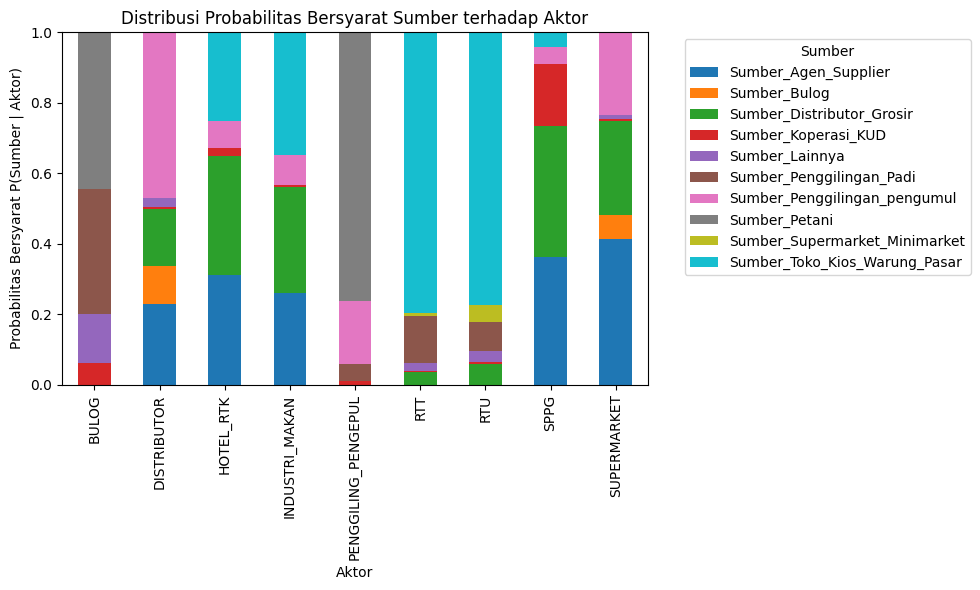

In [112]:
import matplotlib.pyplot as plt

matrix.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Probabilitas Bersyarat P(Sumber | Aktor)")
plt.xlabel("Aktor")
plt.title("Distribusi Probabilitas Bersyarat Sumber terhadap Aktor")
plt.legend(title="Sumber", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

###### Siapa tergantung pada apa, dan seberapa kuat?

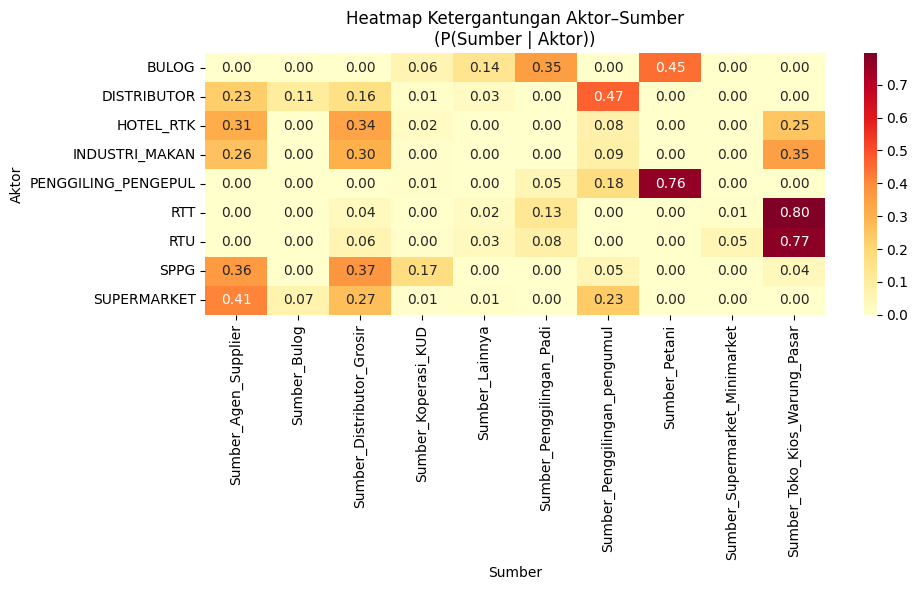

In [113]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title("Heatmap Ketergantungan Aktor–Sumber\n(P(Sumber | Aktor))")
plt.xlabel("Sumber")
plt.ylabel("Aktor")
plt.tight_layout()
plt.show()

###### Siapa yang paling tergantung pada satu sumber?

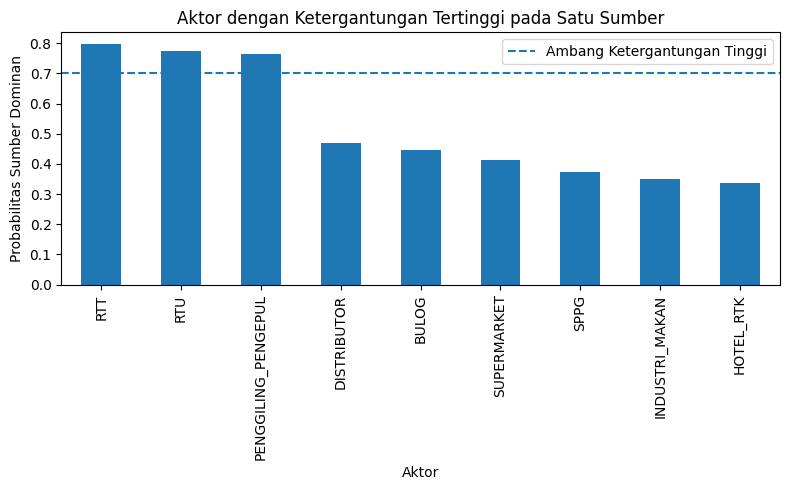

In [114]:
dominance = matrix.max(axis=1).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
dominance.plot(kind='bar')

plt.ylabel("Probabilitas Sumber Dominan")
plt.xlabel("Aktor")
plt.title("Aktor dengan Ketergantungan Tertinggi pada Satu Sumber")
plt.axhline(0.7, linestyle='--', label='Ambang Ketergantungan Tinggi')
plt.legend()
plt.tight_layout()
plt.show()

###### Entropy Plot

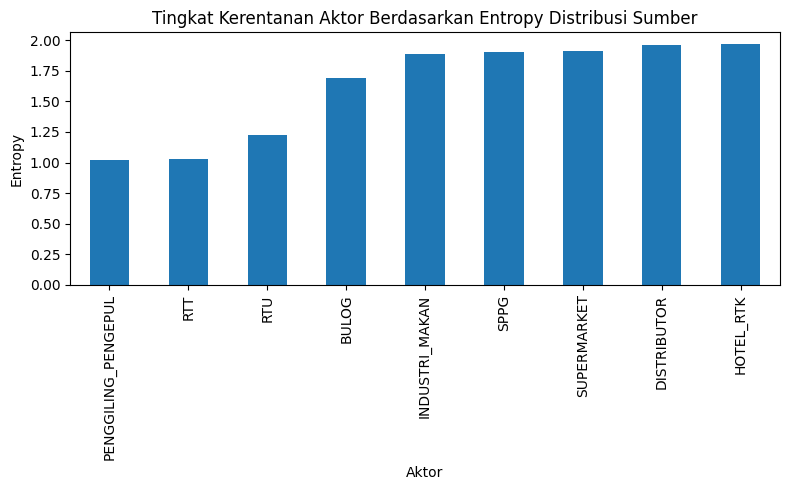

In [115]:
import numpy as np

def entropy(p):
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

entropy_actor = matrix.apply(entropy, axis=1).sort_values()

plt.figure(figsize=(8, 5))
entropy_actor.plot(kind='bar')

plt.ylabel("Entropy")
plt.xlabel("Aktor")
plt.title("Tingkat Kerentanan Aktor Berdasarkan Entropy Distribusi Sumber")
plt.tight_layout()
plt.show()

In [116]:
# dt_all_core
dt_all_core['aktor'].unique()

<ArrowStringArray>
[              'BULOG',         'DISTRIBUTOR',           'HOTEL_RTK',
      'INDUSTRI_MAKAN', 'PENGGILING_PENGEPUL',                 'RTT',
                 'RTU',                'SPPG',         'SUPERMARKET']
Length: 9, dtype: str